# Lib

In [ ]:
import os
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
import math
import random
from collections import defaultdict
from torch.utils.data import Sampler, BatchSampler, DataLoader
import copy


In [2]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.11.0+cu128
torch cuda: 12.8
cuda available: True
gpu: NVIDIA GeForce RTX 2060
capability: (7, 5)


# Data

In [3]:
#dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")
dataset_dir = Path("C:/Users/higher/Desktop/COMPSCI760/Mosquitoes/mosquitoes-compsci760")
image_dir = dataset_dir / "image_crop/image_crop"
annotation_path = image_dir / "cropped_annotations.csv"

annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,source_image
0,train_00000_0_crop.jpeg,340,550,0,0,340,550,albopictus,train_00000.jpeg
1,train_00001_1_crop.jpeg,1050,1093,0,0,1050,1093,albopictus,train_00001.jpeg
2,train_00002_2_crop.jpeg,439,750,0,0,439,750,albopictus,train_00002.jpeg
3,train_00003_3_crop.jpeg,417,462,0,0,417,462,albopictus,train_00003.jpeg
4,train_00004_4_crop.jpeg,568,776,0,0,568,776,culex,train_00004.jpeg


In [4]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10357
class_label
albopictus            4612
culex                 4563
culiseta               622
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000_0_crop.jpeg,albopictus
1,train_00001_1_crop.jpeg,albopictus
2,train_00002_2_crop.jpeg,albopictus
3,train_00003_3_crop.jpeg,albopictus
4,train_00004_4_crop.jpeg,culex


# Preprocessing

In [5]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

In [6]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7249
Val: 1554
Test: 1554


In [7]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# Count samples per class
class_counts = train_df["label_id"].value_counts().sort_index()
print(class_counts)

class_weights = 1.0 / class_counts
print(class_weights)

label_id
0      33
1    3228
2      59
3    3194
4     435
5     300
Name: count, dtype: int64
label_id
0    0.030303
1    0.000310
2    0.016949
3    0.000313
4    0.002299
5    0.003333
Name: count, dtype: float64


In [8]:
train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)

val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

print("Subset Train:", len(train_subset_df))
print("Subset Val:", len(val_subset_df))
print("Subset Test:", len(test_subset_df))

Subset Train: 283
Subset Val: 99
Subset Test: 100


# Modeling

## ENV

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Using: cuda
GPU: NVIDIA GeForce RTX 2060
Capability: (7, 5)


## Transform

In [10]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Dataset

In [11]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        #self.image_paths = df["label_id"].values
        #self.labels = df.iloc[:, -1].values
        self.image_paths = df['img_fName'].astype(str).values
        self.labels = df['label_id'].values

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_dir / self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [13]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)

def create_model(model_name, num_classes):
    if model_name == "efficientnet":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "mobilenet":
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model

In [14]:
# WeightedRandomSampler
sample_weights = train_df["label_id"].map(class_weights).values
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # same size as train set
    replacement=True
)

# Sampler method
train_loader = DataLoader(
    train_dataset,   # your PyTorch Dataset
    batch_size=32,
    sampler=sampler,
    shuffle=False    # IMPORTANT: must be False when using sampler
)



# FocalLoss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none') 
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()



# PF-Loss
#PF-loss is not weighted loss and not sampler-based
class PFLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, inputs, targets):
        num_classes = inputs.size(1)

        probs = F.softmax(inputs, dim=1)
        true_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        class_means = []
        for c in range(num_classes):
            mask = (targets == c)
            if mask.any():
                q_c = true_probs[mask].mean()
            else:
                q_c = inputs.new_tensor(1.0)  # no loss contribution if class absent in batch
            class_means.append(q_c)

        class_means = torch.stack(class_means)
        loss = -torch.log(class_means + self.eps).mean()
        return loss



# StratifiedBatchSampler
class StratifiedBatchSampler(BatchSampler):
    def __init__(self, labels, batch_size, shuffle=True):
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_indices = {}
        for c in np.unique(self.labels):
            self.class_indices[c] = np.where(self.labels == c)[0].tolist()

        self.classes = list(self.class_indices.keys())
        self.num_classes = len(self.classes)
        self.num_batches = math.ceil(len(self.labels) / self.batch_size)

    def __iter__(self):
        pools = {c: idxs.copy() for c, idxs in self.class_indices.items()}

        if self.shuffle:
            for c in pools:
                random.shuffle(pools[c])

        for _ in range(self.num_batches):
            batch = []

            base = self.batch_size // self.num_classes
            remainder = self.batch_size % self.num_classes

            per_class = {c: base for c in self.classes}
            for c in self.classes[:remainder]:
                per_class[c] += 1

            for c in self.classes:
                need = per_class[c]

                if len(pools[c]) < need:
                    refill = self.class_indices[c].copy()
                    if self.shuffle:
                        random.shuffle(refill)
                    pools[c].extend(refill)

                batch.extend(pools[c][:need])
                pools[c] = pools[c][need:]

            if self.shuffle:
                random.shuffle(batch)

            yield batch

    def __len__(self):
        return self.num_batches

In [15]:
def run_experiment(model_name, method_name, class_weights_tensor=None):
    val_acc_history = []

    model = create_model(model_name, num_classes)
    model = model.to(device)

    # freeze all
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze last layers
    if model_name == "efficientnet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "resnet50":
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "mobilenet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4
    )

    # =========================
    # BALANCING METHODS
    # =========================

    if method_name == "weighted_sampler":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=32,
            sampler=sampler,
            shuffle=False
        )

    elif method_name == "weighted_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "focal_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True
        )
        criterion = FocalLoss(gamma=1.0, weight=class_weights_tensor)

    elif method_name == "pf_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True
        )
        criterion = PFLoss()

    elif method_name == "stratified_sampling":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=32,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss()    

    else:
        train_loader_used = train_loader
        criterion = nn.CrossEntropyLoss()

    print(f"\n===== Training {model_name} with {method_name} =====")

    output_dir = Path("/kaggle/Output")
    output_dir.mkdir(parents=True, exist_ok=True)

    num_epochs = 25
    patience = 5
    best_val_loss = float("inf")
    early_stop_counter = 0

    best_val_acc = 0
    val_acc = 0  # IMPORTANT FIX

    for epoch in range(num_epochs):
        print(f"\n===== Epoch {epoch + 1}/{num_epochs} =====")

        # ================= TRAIN =================
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, targets) in enumerate(train_loader_used):
            images = images.to(device, non_blocking=True)
            targets = targets.long().to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            train_correct += (preds == targets).sum().item()
            train_total += targets.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, (images, targets) in enumerate(val_loader):
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)

                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        val_acc_history.append(val_acc)

        print(
            f"Epoch {epoch + 1} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ================= CHECKPOINT =================
        checkpoint_path = output_dir / f"{model_name}_epoch_{epoch + 1}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "class_names": class_names
        }, checkpoint_path)

        # ================= EARLY STOPPING =================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0

            best_model_path = output_dir / f"{model_name}_best.pth"
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "class_names": class_names
            }, best_model_path)

        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

    return {
        "model": model_name,
        "method": method_name,
        "val_acc_history": val_acc_history,
        "best_val_acc": max(val_acc_history),
        "final_val_acc": val_acc,
        "model_obj": model
    }

In [16]:
# train all combinations
models_list = ["efficientnet", "resnet50", "mobilenet"]
methods_list = ["weighted_sampler", "weighted_loss", "focal_loss", "pf_loss", "stratified_sampling"]

all_results = []
trained_models = {}

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

for model_name in models_list:
    for method_name in methods_list:

        result = run_experiment(
            model_name,
            method_name,
            class_weights_tensor
        )

        # store results
        all_results.append(result)

        key = f"{model_name}_{method_name}"
        trained_models[key] = result["model_obj"]


===== Training efficientnet with weighted_sampler =====

===== Epoch 1/25 =====
Epoch 1 | Train Loss: 1.3256 | Train Acc: 0.5359 | Val Loss: 0.9642 | Val Acc: 0.6828

===== Epoch 2/25 =====
Epoch 2 | Train Loss: 0.8153 | Train Acc: 0.7218 | Val Loss: 0.7998 | Val Acc: 0.7072

===== Epoch 3/25 =====
Epoch 3 | Train Loss: 0.6086 | Train Acc: 0.7891 | Val Loss: 0.6809 | Val Acc: 0.7420

===== Epoch 4/25 =====
Epoch 4 | Train Loss: 0.5006 | Train Acc: 0.8225 | Val Loss: 0.6586 | Val Acc: 0.7510

===== Epoch 5/25 =====
Epoch 5 | Train Loss: 0.4363 | Train Acc: 0.8498 | Val Loss: 0.6479 | Val Acc: 0.7503

===== Epoch 6/25 =====
Epoch 6 | Train Loss: 0.3760 | Train Acc: 0.8665 | Val Loss: 0.6127 | Val Acc: 0.7690

===== Epoch 7/25 =====
Epoch 7 | Train Loss: 0.3238 | Train Acc: 0.8829 | Val Loss: 0.5510 | Val Acc: 0.8024

===== Epoch 8/25 =====
Epoch 8 | Train Loss: 0.2927 | Train Acc: 0.8965 | Val Loss: 0.5372 | Val Acc: 0.8044

===== Epoch 9/25 =====
Epoch 9 | Train Loss: 0.2774 | Train Ac

In [17]:
# collect test predictions
all_test_results = {}

for name, model in trained_models.items():
    print(f"\nEvaluating {name}...")

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_test_results[name] = {
        "probs": np.concatenate(all_probs),
        "preds": np.concatenate(all_preds),
        "labels": np.concatenate(all_labels)
    }


Evaluating efficientnet_weighted_sampler...

Evaluating efficientnet_weighted_loss...

Evaluating efficientnet_focal_loss...

Evaluating efficientnet_pf_loss...

Evaluating efficientnet_stratified_sampling...

Evaluating resnet50_weighted_sampler...

Evaluating resnet50_weighted_loss...

Evaluating resnet50_focal_loss...

Evaluating resnet50_pf_loss...

Evaluating resnet50_stratified_sampling...

Evaluating mobilenet_weighted_sampler...

Evaluating mobilenet_weighted_loss...

Evaluating mobilenet_focal_loss...

Evaluating mobilenet_pf_loss...

Evaluating mobilenet_stratified_sampling...



Detailed Evaluation: efficientnet_weighted_sampler
Accuracy:           0.8559
Balanced Accuracy:  0.5118
Macro Precision:    0.4889
Macro Recall:       0.5118
Macro F1:           0.4970
Weighted Precision: 0.8653
Weighted Recall:    0.8559
Weighted F1:        0.8596

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.200000  0.142857  0.166667        7
1          albopictus   0.932229  0.894509  0.912979      692
2           anopheles   0.000000  0.000000  0.000000       13
3               culex   0.917160  0.906433  0.911765      684
4            culiseta   0.474576  0.595745  0.528302       94
5  japonicus-koreicus   0.409639  0.531250  0.462585       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2000    0.1429    0.1667         7
        albopictus     0.9322    0.8945    0.9130       692
         anopheles     0.0000    0.0000    0.0000        13
             

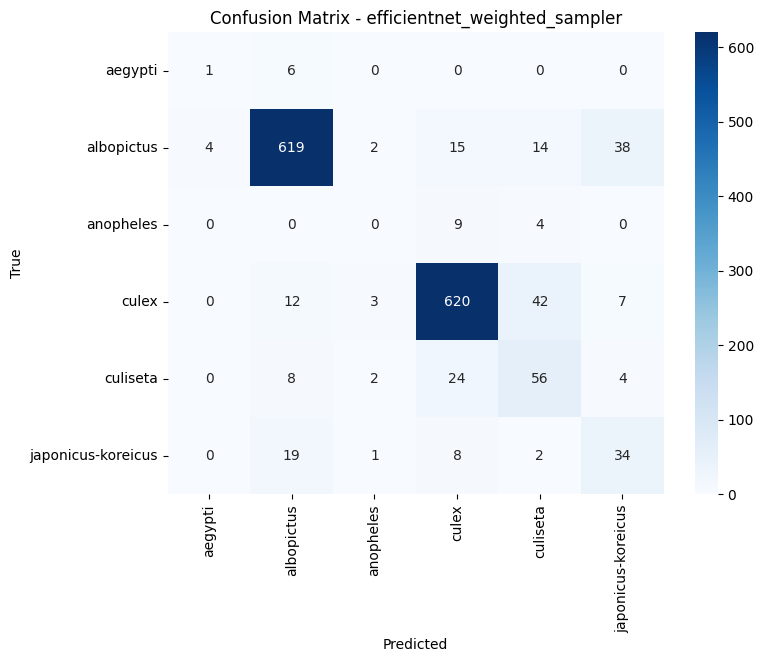


Detailed Evaluation: efficientnet_weighted_loss
Accuracy:           0.7831
Balanced Accuracy:  0.6049
Macro Precision:    0.4685
Macro Recall:       0.6049
Macro F1:           0.4835
Weighted Precision: 0.8784
Weighted Recall:    0.7831
Weighted F1:        0.8217

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.074074  0.285714  0.117647        7
1          albopictus   0.952623  0.813584  0.877631      692
2           anopheles   0.070000  0.538462  0.123894       13
3               culex   0.935702  0.808480  0.867451      684
4            culiseta   0.485714  0.542553  0.512563       94
5  japonicus-koreicus   0.292857  0.640625  0.401961       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0741    0.2857    0.1176         7
        albopictus     0.9526    0.8136    0.8776       692
         anopheles     0.0700    0.5385    0.1239        13
             cul

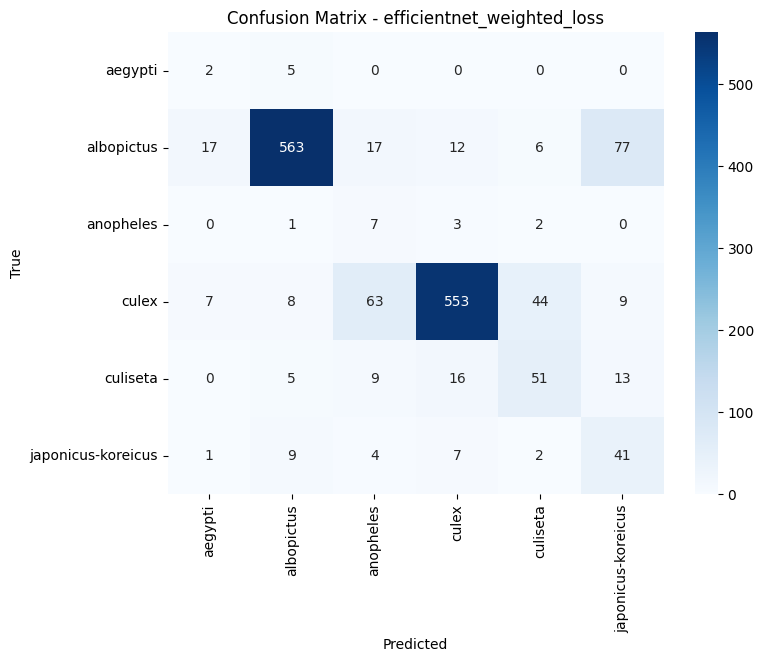


Detailed Evaluation: efficientnet_focal_loss
Accuracy:           0.1017
Balanced Accuracy:  0.4195
Macro Precision:    0.3957
Macro Recall:       0.4195
Macro F1:           0.1176
Weighted Precision: 0.9047
Weighted Recall:    0.1017
Weighted F1:        0.1023

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.016835  0.714286  0.032895        7
1          albopictus   1.000000  0.040462  0.077778      692
2           anopheles   0.015180  0.615385  0.029630       13
3               culex   1.000000  0.049708  0.094708      684
4            culiseta   0.258065  0.425532  0.321285       94
5  japonicus-koreicus   0.083821  0.671875  0.149047       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0168    0.7143    0.0329         7
        albopictus     1.0000    0.0405    0.0778       692
         anopheles     0.0152    0.6154    0.0296        13
             culex 

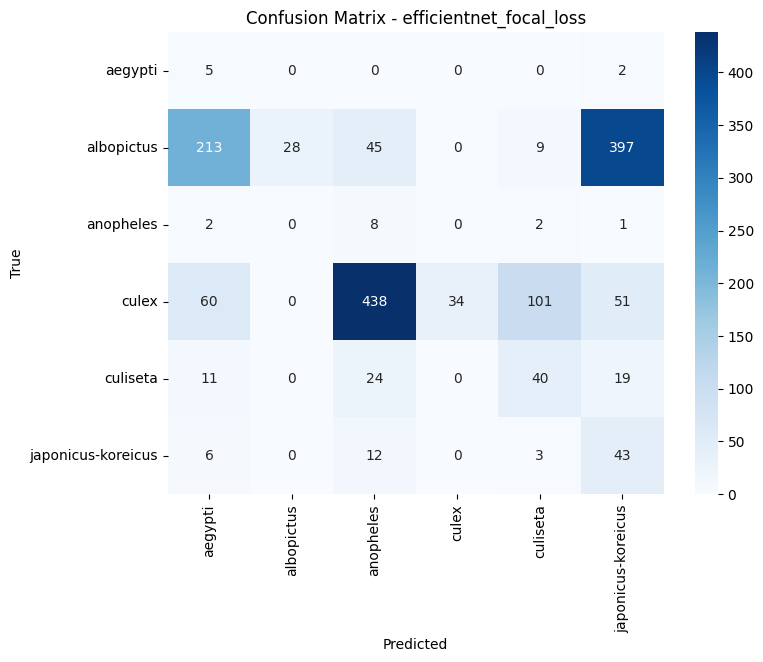


Detailed Evaluation: efficientnet_pf_loss
Accuracy:           0.7587
Balanced Accuracy:  0.5571
Macro Precision:    0.4437
Macro Recall:       0.5571
Macro F1:           0.4546
Weighted Precision: 0.8772
Weighted Recall:    0.7587
Weighted F1:        0.8034

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.062500  0.142857  0.086957        7
1          albopictus   0.951786  0.770231  0.851438      692
2           anopheles   0.083333  0.384615  0.136986       13
3               culex   0.952632  0.793860  0.866029      684
4            culiseta   0.410853  0.563830  0.475336       94
5  japonicus-koreicus   0.200913  0.687500  0.310954       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0625    0.1429    0.0870         7
        albopictus     0.9518    0.7702    0.8514       692
         anopheles     0.0833    0.3846    0.1370        13
             culex    

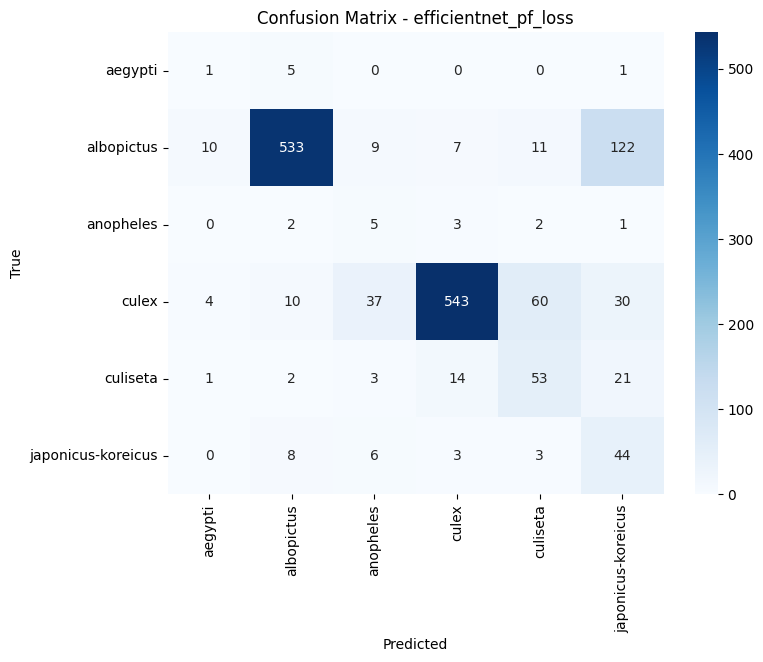


Detailed Evaluation: efficientnet_stratified_sampling
Accuracy:           0.8636
Balanced Accuracy:  0.5275
Macro Precision:    0.5260
Macro Recall:       0.5275
Macro F1:           0.5214
Weighted Precision: 0.8708
Weighted Recall:    0.8636
Weighted F1:        0.8663

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.926794  0.914740  0.920727      692
2           anopheles   0.066667  0.076923  0.071429       13
3               culex   0.918398  0.904971  0.911635      684
4            culiseta   0.581395  0.531915  0.555556       94
5  japonicus-koreicus   0.413043  0.593750  0.487179       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9268    0.9147    0.9207       692
         anopheles     0.0667    0.0769    0.0714        13
          

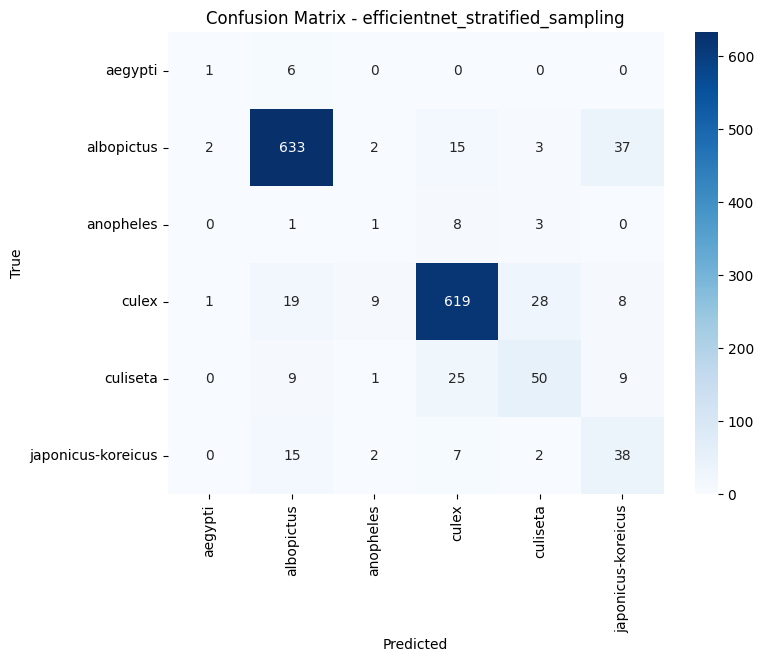


Detailed Evaluation: resnet50_weighted_sampler
Accuracy:           0.9099
Balanced Accuracy:  0.5670
Macro Precision:    0.7709
Macro Recall:       0.5670
Macro F1:           0.6077
Weighted Precision: 0.9037
Weighted Recall:    0.9099
Weighted F1:        0.9036

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.142857  0.250000        7
1          albopictus   0.947598  0.940751  0.944162      692
2           anopheles   0.375000  0.230769  0.285714       13
3               culex   0.913580  0.973684  0.942675      684
4            culiseta   0.764045  0.723404  0.743169       94
5  japonicus-koreicus   0.625000  0.390625  0.480769       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.1429    0.2500         7
        albopictus     0.9476    0.9408    0.9442       692
         anopheles     0.3750    0.2308    0.2857        13
             cule

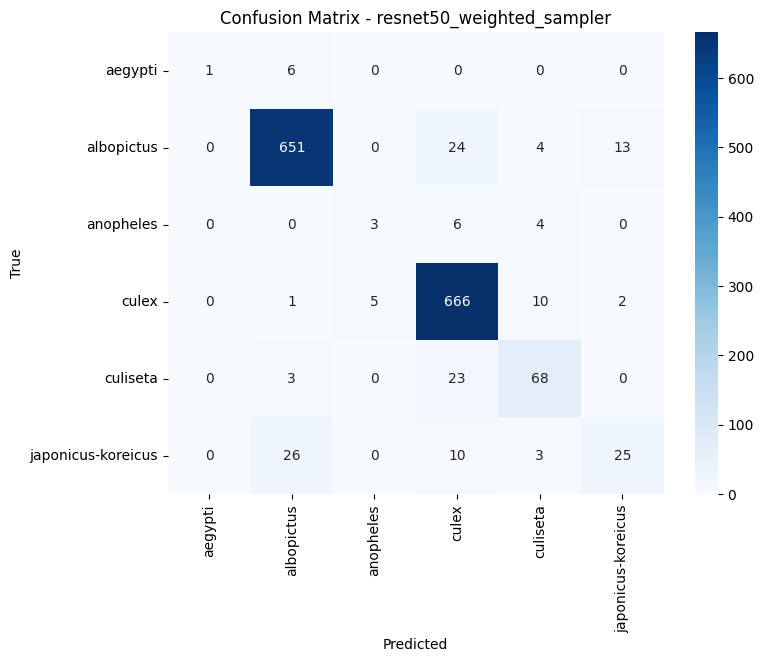


Detailed Evaluation: resnet50_weighted_loss
Accuracy:           0.8616
Balanced Accuracy:  0.5405
Macro Precision:    0.4912
Macro Recall:       0.5405
Macro F1:           0.5060
Weighted Precision: 0.8887
Weighted Recall:    0.8616
Weighted F1:        0.8726

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.040000  0.142857  0.062500        7
1          albopictus   0.938623  0.906069  0.922059      692
2           anopheles   0.000000  0.000000  0.000000       13
3               culex   0.949527  0.880117  0.913505      684
4            culiseta   0.549296  0.829787  0.661017       94
5  japonicus-koreicus   0.469697  0.484375  0.476923       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0400    0.1429    0.0625         7
        albopictus     0.9386    0.9061    0.9221       692
         anopheles     0.0000    0.0000    0.0000        13
             culex  

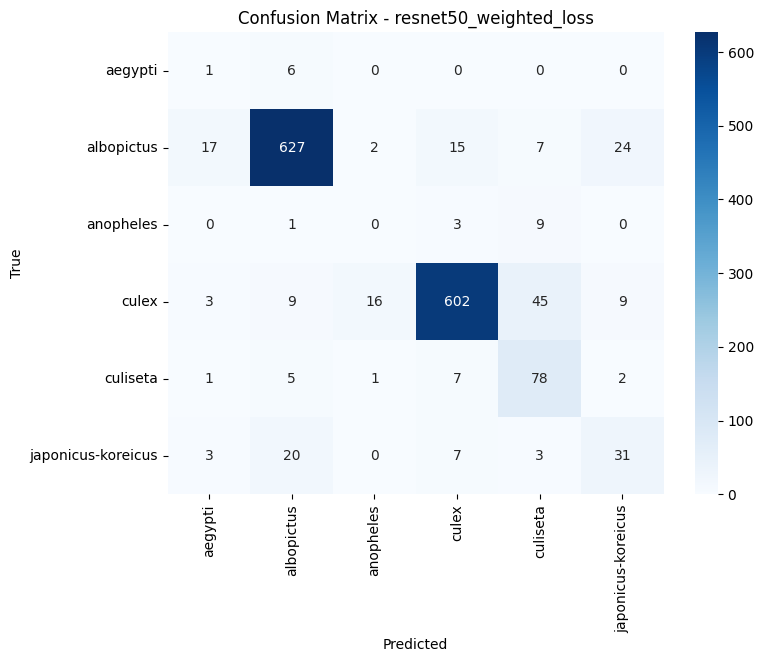


Detailed Evaluation: resnet50_focal_loss
Accuracy:           0.0862
Balanced Accuracy:  0.3717
Macro Precision:    0.3770
Macro Recall:       0.3717
Macro F1:           0.0930
Weighted Precision: 0.8983
Weighted Recall:    0.0862
Weighted F1:        0.0796

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.012821  0.571429  0.025078        7
1          albopictus   1.000000  0.020231  0.039660      692
2           anopheles   0.016014  0.692308  0.031304       13
3               culex   1.000000  0.049708  0.094708      684
4            culiseta   0.159091  0.521277  0.243781       94
5  japonicus-koreicus   0.074074  0.375000  0.123711       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0128    0.5714    0.0251         7
        albopictus     1.0000    0.0202    0.0397       692
         anopheles     0.0160    0.6923    0.0313        13
             culex     

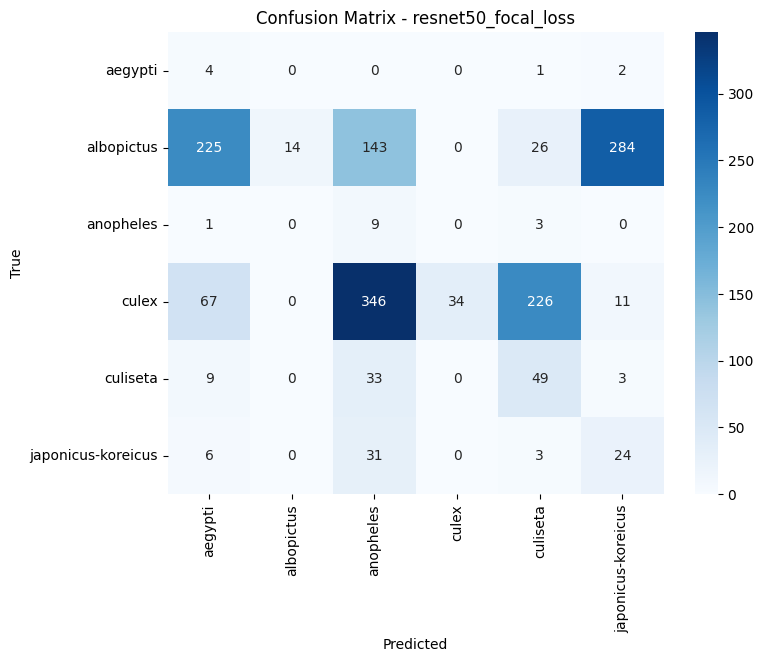


Detailed Evaluation: resnet50_pf_loss
Accuracy:           0.7638
Balanced Accuracy:  0.5567
Macro Precision:    0.4462
Macro Recall:       0.5567
Macro F1:           0.4594
Weighted Precision: 0.8851
Weighted Recall:    0.7638
Weighted F1:        0.8051

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.052632  0.142857  0.076923        7
1          albopictus   0.972167  0.706647  0.818410      692
2           anopheles   0.048780  0.153846  0.074074       13
3               culex   0.944171  0.840643  0.889404      684
4            culiseta   0.455090  0.808511  0.582375       94
5  japonicus-koreicus   0.204651  0.687500  0.315412       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0526    0.1429    0.0769         7
        albopictus     0.9722    0.7066    0.8184       692
         anopheles     0.0488    0.1538    0.0741        13
             culex     0.9

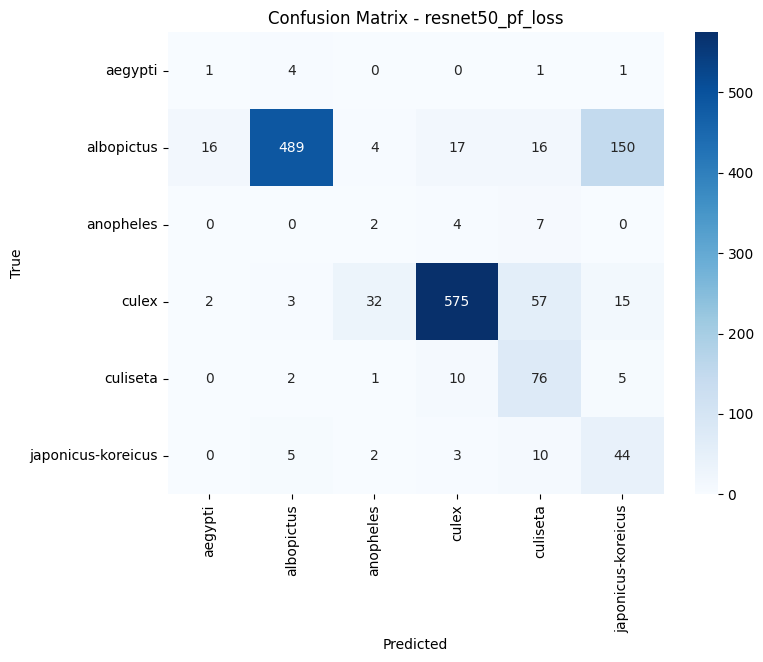


Detailed Evaluation: resnet50_stratified_sampling
Accuracy:           0.9060
Balanced Accuracy:  0.6018
Macro Precision:    0.7756
Macro Recall:       0.6018
Macro F1:           0.6268
Weighted Precision: 0.9106
Weighted Recall:    0.9060
Weighted F1:        0.9050

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.285714  0.444444        7
1          albopictus   0.957768  0.917630  0.937269      692
2           anopheles   0.500000  0.076923  0.133333       13
3               culex   0.925770  0.966374  0.945637      684
4            culiseta   0.809524  0.723404  0.764045       94
5  japonicus-koreicus   0.460674  0.640625  0.535948       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.2857    0.4444         7
        albopictus     0.9578    0.9176    0.9373       692
         anopheles     0.5000    0.0769    0.1333        13
             c

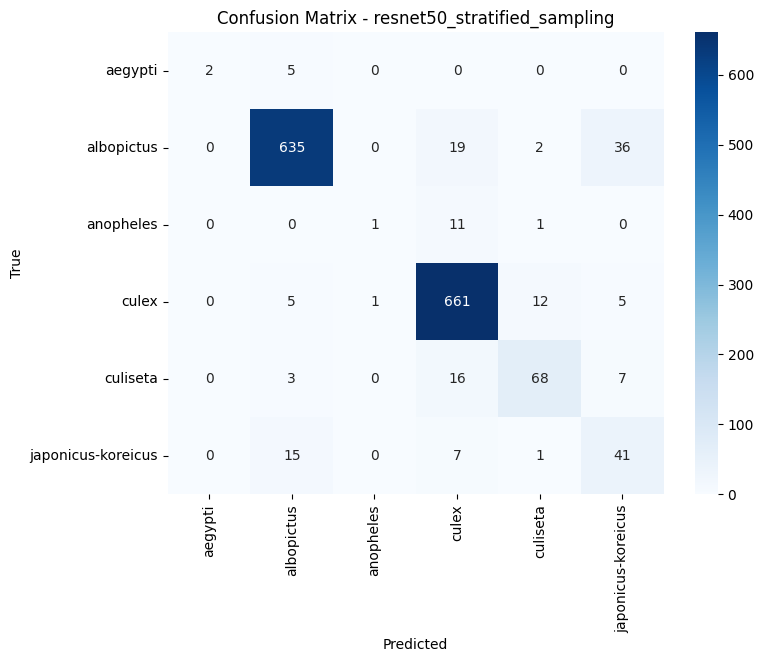


Detailed Evaluation: mobilenet_weighted_sampler
Accuracy:           0.8353
Balanced Accuracy:  0.5111
Macro Precision:    0.4712
Macro Recall:       0.5111
Macro F1:           0.4815
Weighted Precision: 0.8628
Weighted Recall:    0.8353
Weighted F1:        0.8460

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.930341  0.868497  0.898356      692
2           anopheles   0.222222  0.153846  0.181818       13
3               culex   0.924731  0.880117  0.901873      684
4            culiseta   0.453125  0.617021  0.522523       94
5  japonicus-koreicus   0.296610  0.546875  0.384615       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9303    0.8685    0.8984       692
         anopheles     0.2222    0.1538    0.1818        13
             cul

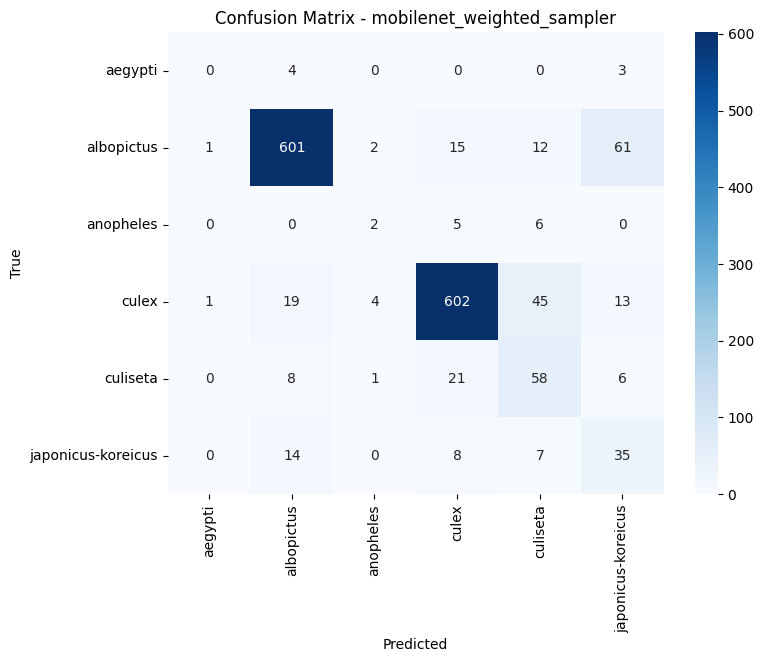


Detailed Evaluation: mobilenet_weighted_loss
Accuracy:           0.7896
Balanced Accuracy:  0.5604
Macro Precision:    0.4593
Macro Recall:       0.5604
Macro F1:           0.4853
Weighted Precision: 0.8623
Weighted Recall:    0.7896
Weighted F1:        0.8172

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.142857  0.285714  0.190476        7
1          albopictus   0.932119  0.813584  0.868827      692
2           anopheles   0.130435  0.230769  0.166667       13
3               culex   0.938127  0.820175  0.875195      684
4            culiseta   0.380952  0.680851  0.488550       94
5  japonicus-koreicus   0.231293  0.531250  0.322275       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.1429    0.2857    0.1905         7
        albopictus     0.9321    0.8136    0.8688       692
         anopheles     0.1304    0.2308    0.1667        13
             culex 

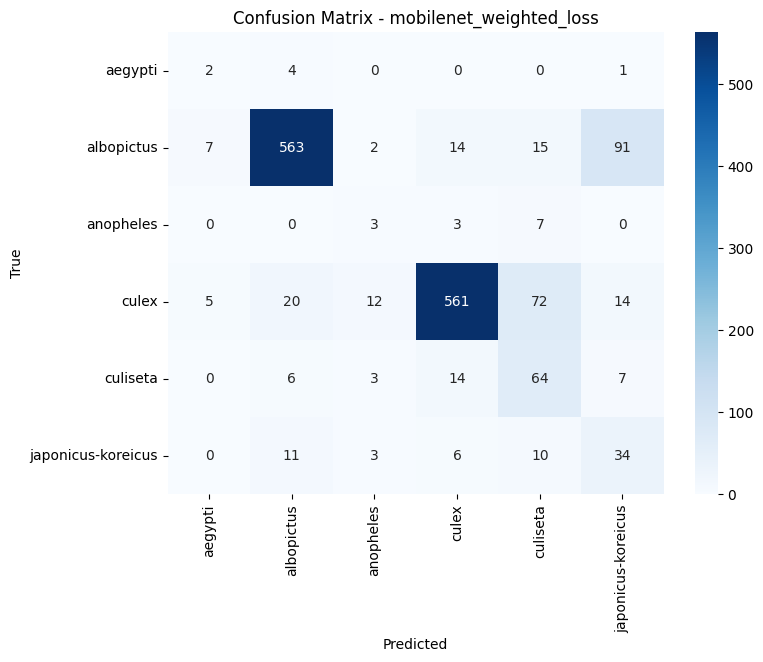


Detailed Evaluation: mobilenet_focal_loss
Accuracy:           0.0541
Balanced Accuracy:  0.4208
Macro Precision:    0.0675
Macro Recall:       0.4208
Macro F1:           0.0900
Weighted Precision: 0.0208
Weighted Recall:    0.0541
Weighted F1:        0.0260

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.009940  0.714286  0.019608        7
1          albopictus   0.000000  0.000000  0.000000      692
2           anopheles   0.019544  0.923077  0.038278       13
3               culex   0.000000  0.000000  0.000000      684
4            culiseta   0.264463  0.340426  0.297674       94
5  japonicus-koreicus   0.110759  0.546875  0.184211       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0099    0.7143    0.0196         7
        albopictus     0.0000    0.0000    0.0000       692
         anopheles     0.0195    0.9231    0.0383        13
             culex    

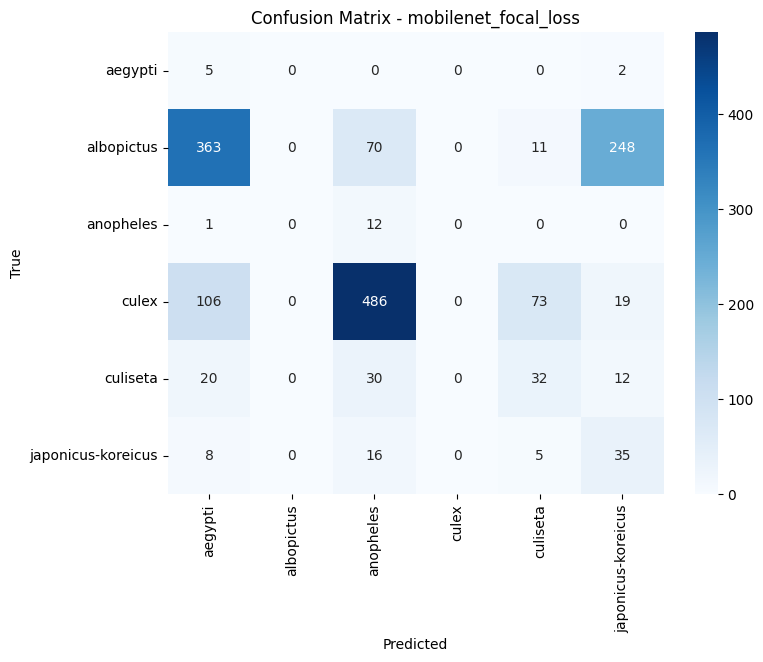


Detailed Evaluation: mobilenet_pf_loss
Accuracy:           0.7851
Balanced Accuracy:  0.6200
Macro Precision:    0.4857
Macro Recall:       0.6200
Macro F1:           0.5168
Weighted Precision: 0.8721
Weighted Recall:    0.7851
Weighted F1:        0.8166

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.428571  0.315789        7
1          albopictus   0.953368  0.797688  0.868607      692
2           anopheles   0.121212  0.307692  0.173913       13
3               culex   0.932432  0.807018  0.865204      684
4            culiseta   0.414013  0.691489  0.517928       94
5  japonicus-koreicus   0.243094  0.687500  0.359184       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.4286    0.3158         7
        albopictus     0.9534    0.7977    0.8686       692
         anopheles     0.1212    0.3077    0.1739        13
             culex     0.

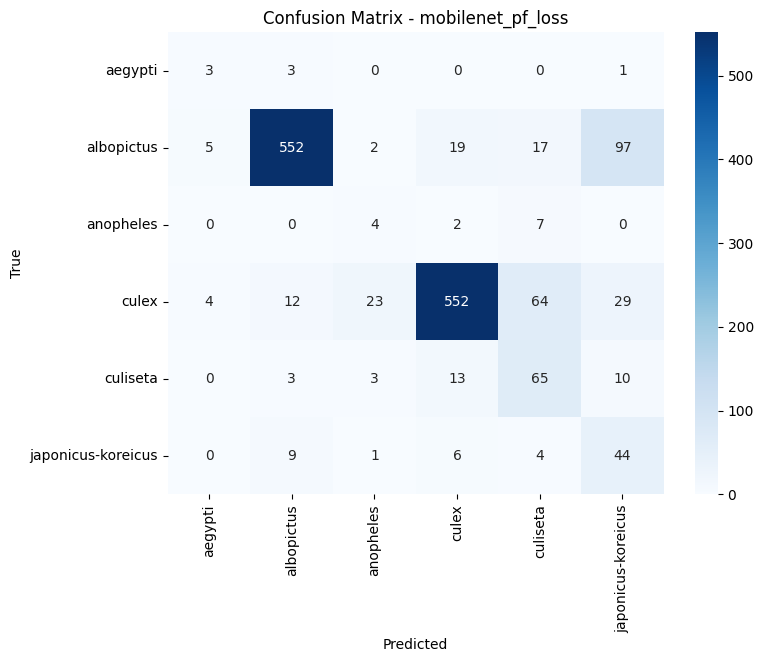


Detailed Evaluation: mobilenet_stratified_sampling
Accuracy:           0.8649
Balanced Accuracy:  0.4715
Macro Precision:    0.4974
Macro Recall:       0.4715
Macro F1:           0.4767
Weighted Precision: 0.8571
Weighted Recall:    0.8649
Weighted F1:        0.8604

Per-class metrics:
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.925329  0.913295  0.919273      692
2           anopheles   0.250000  0.076923  0.117647       13
3               culex   0.898592  0.932749  0.915352      684
4            culiseta   0.516484  0.500000  0.508108       94
5  japonicus-koreicus   0.393939  0.406250  0.400000       64

Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9253    0.9133    0.9193       692
         anopheles     0.2500    0.0769    0.1176        13
             

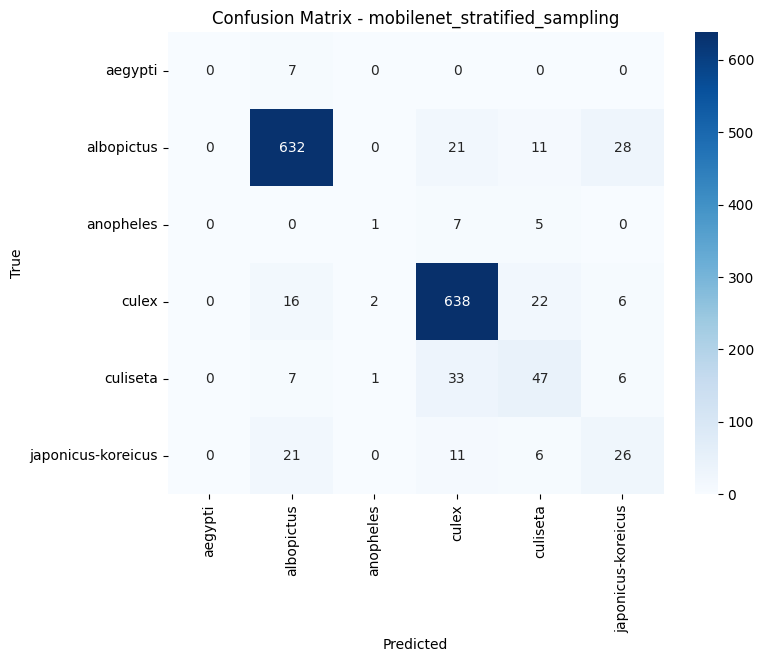

In [ ]:
# detailed imbalance evaluation

detailed_eval_list = []

for model_name, data in all_test_results.items():
    print(f"\n==============================")
    print(f"Detailed Evaluation: {model_name}")
    print(f"==============================")

    all_preds = data["preds"]
    all_labels = data["labels"]
    all_probs = data["probs"]

    # Overall metrics
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Print overall metrics
    print(f"Accuracy:           {acc:.4f}")
    print(f"Balanced Accuracy:  {bal_acc:.4f}")
    print(f"Macro Precision:    {precision_macro:.4f}")
    print(f"Macro Recall:       {recall_macro:.4f}")
    print(f"Macro F1:           {f1_macro:.4f}")
    print(f"Weighted Precision: {precision_weighted:.4f}")
    print(f"Weighted Recall:    {recall_weighted:.4f}")
    print(f"Weighted F1:        {f1_weighted:.4f}")

    # Per-class table
    per_class_df = pd.DataFrame({
        "class_name": class_names,
        "precision": precision_per_class,
        "recall": recall_per_class,
        "f1": f1_per_class,
        "support": support
    })

    print("\nPer-class metrics:")
    print(per_class_df)

    print("\nClassification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

    print("\nConfusion matrix:")
    print(cm)

    # Confusion matrix plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Store overall metrics
    detailed_eval_list.append({
        "model": model_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    })

In [20]:
detailed_eval_df = pd.DataFrame(detailed_eval_list)

print("\n===== Detailed Evaluation Summary =====")
print(detailed_eval_df.sort_values(by="macro_f1", ascending=False))


===== Detailed Evaluation Summary =====
                               model  accuracy  balanced_accuracy  \
9       resnet50_stratified_sampling  0.906049           0.601778   
5          resnet50_weighted_sampler  0.909910           0.567015   
4   efficientnet_stratified_sampling  0.863578           0.527526   
13                 mobilenet_pf_loss  0.785071           0.619993   
6             resnet50_weighted_loss  0.861647           0.540534   
0      efficientnet_weighted_sampler  0.855856           0.511799   
11           mobilenet_weighted_loss  0.789575           0.560391   
1         efficientnet_weighted_loss  0.783140           0.604903   
10        mobilenet_weighted_sampler  0.835264           0.511059   
14     mobilenet_stratified_sampling  0.864865           0.471536   
8                   resnet50_pf_loss  0.763835           0.556667   
3               efficientnet_pf_loss  0.758687           0.557149   
2            efficientnet_focal_loss  0.101673           0.419

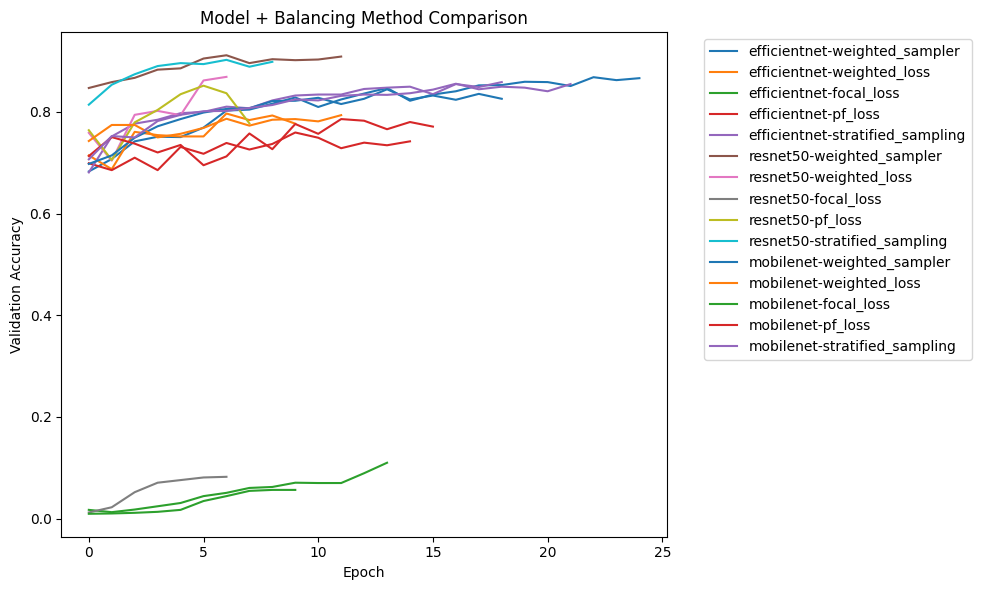

efficientnet + weighted_sampler → Best: 0.8681
efficientnet + weighted_loss → Best: 0.7967
efficientnet + focal_loss → Best: 0.1100
efficientnet + pf_loss → Best: 0.7593
efficientnet + stratified_sampling → Best: 0.8584
resnet50 + weighted_sampler → Best: 0.9112
resnet50 + weighted_loss → Best: 0.8687
resnet50 + focal_loss → Best: 0.0824
resnet50 + pf_loss → Best: 0.8514
resnet50 + stratified_sampling → Best: 0.9022
mobilenet + weighted_sampler → Best: 0.8443
mobilenet + weighted_loss → Best: 0.7934
mobilenet + focal_loss → Best: 0.0566
mobilenet + pf_loss → Best: 0.7857
mobilenet + stratified_sampling → Best: 0.8552


In [21]:
# validation accuracy plot
plt.figure(figsize=(10,6))

for r in all_results:
    label = f"{r['model']}-{r['method']}"
    plt.plot(r["val_acc_history"], label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Model + Balancing Method Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

for r in all_results:
    print(f"{r['model']} + {r['method']} → Best: {r['best_val_acc']:.4f}")



===== Results for efficientnet_weighted_sampler =====
Test Accuracy: 0.8559


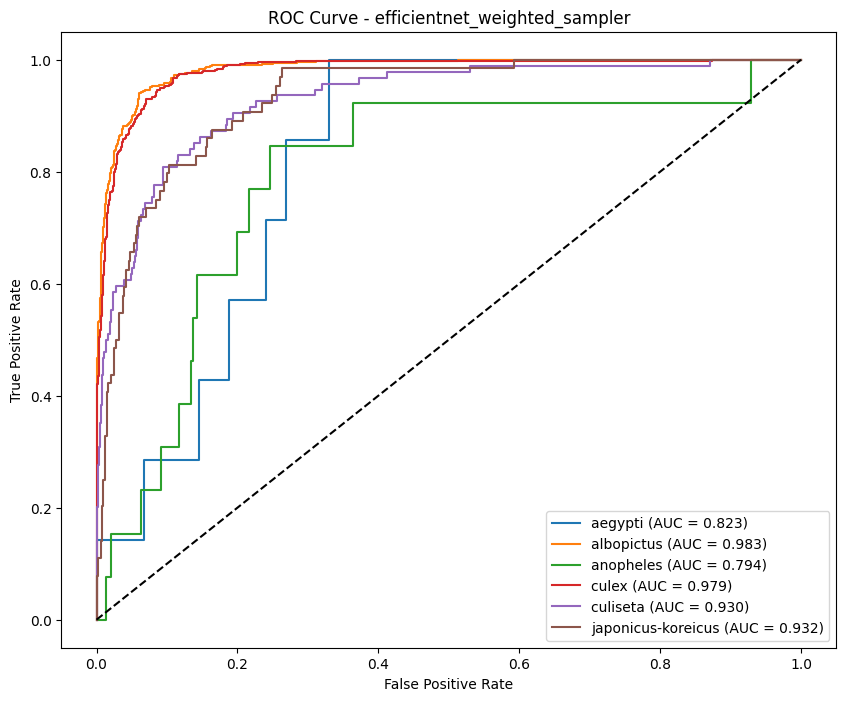

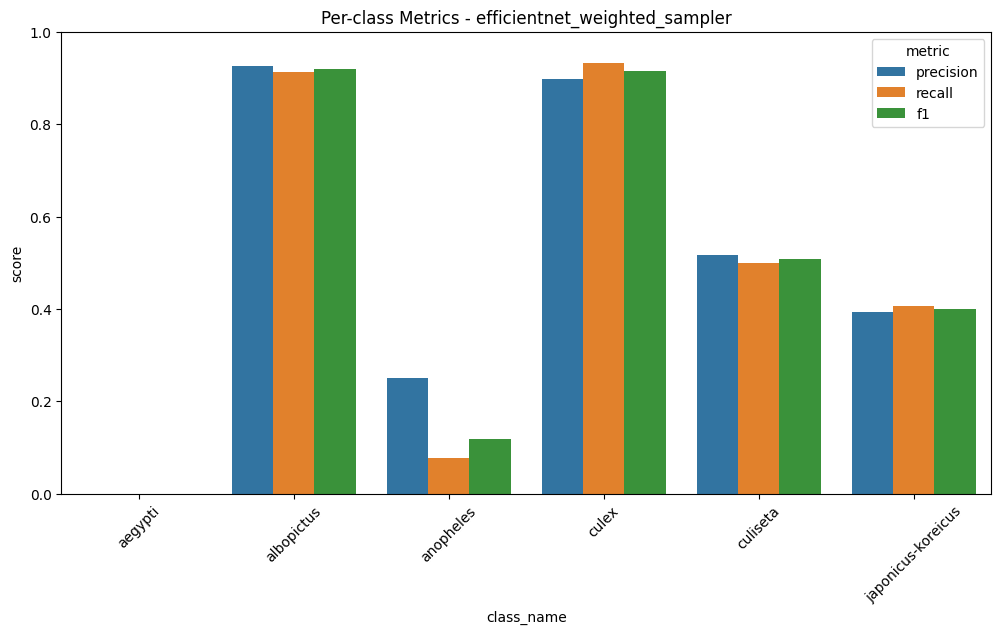


===== Results for efficientnet_weighted_loss =====
Test Accuracy: 0.7831


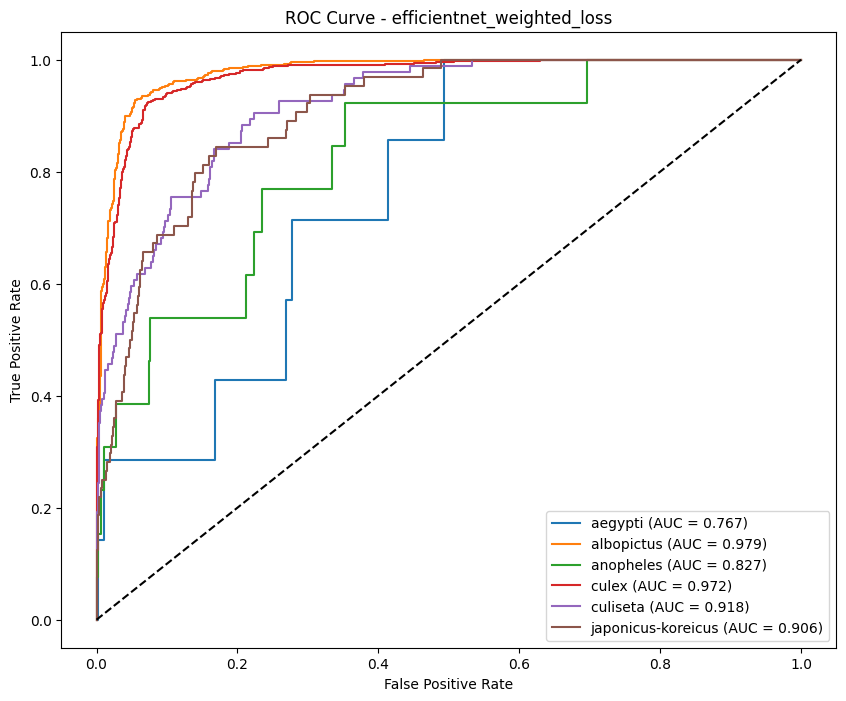

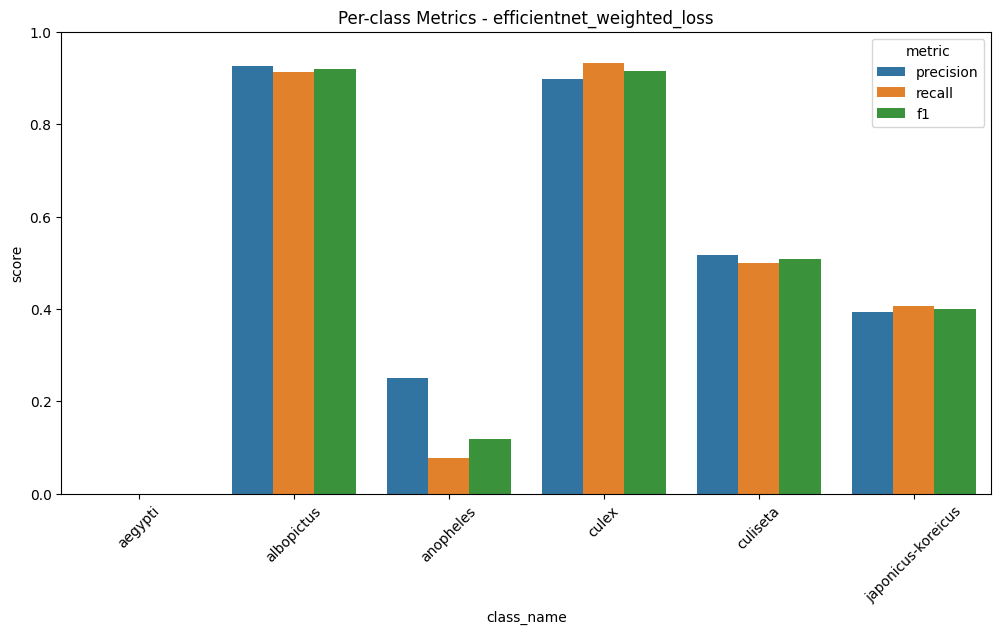


===== Results for efficientnet_focal_loss =====
Test Accuracy: 0.1017


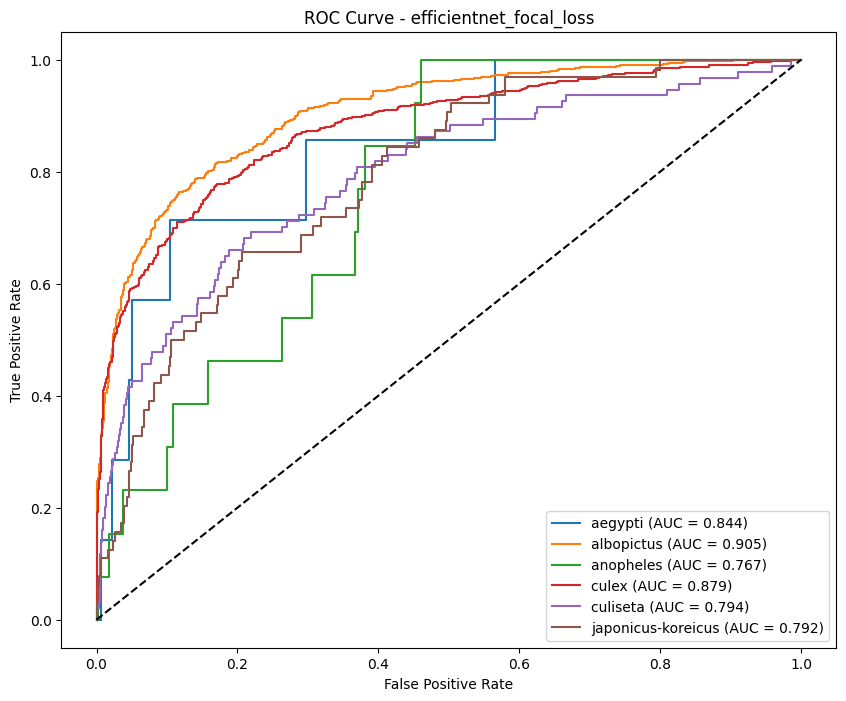

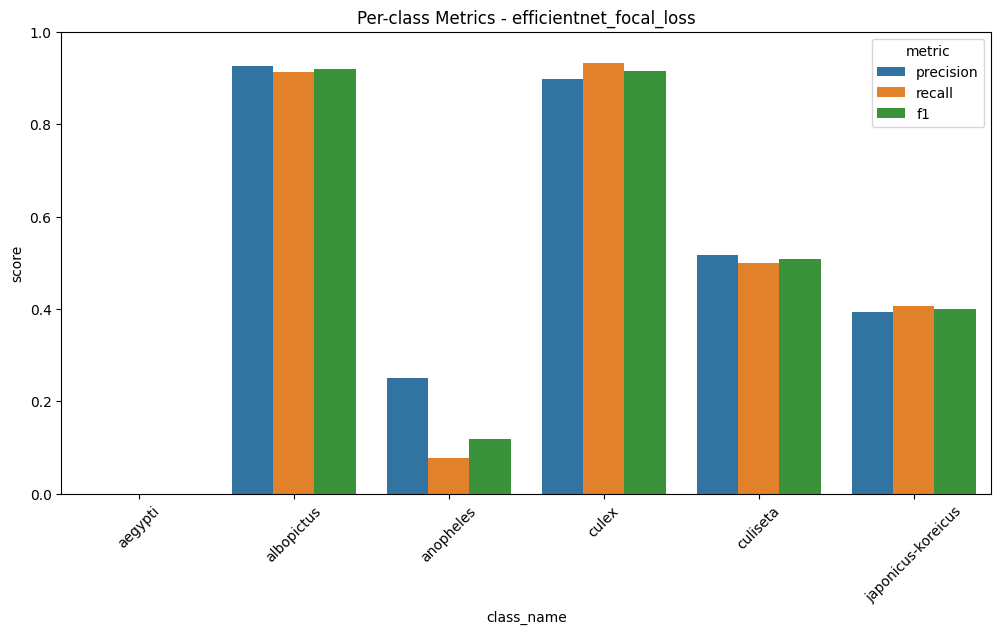


===== Results for efficientnet_pf_loss =====
Test Accuracy: 0.7587


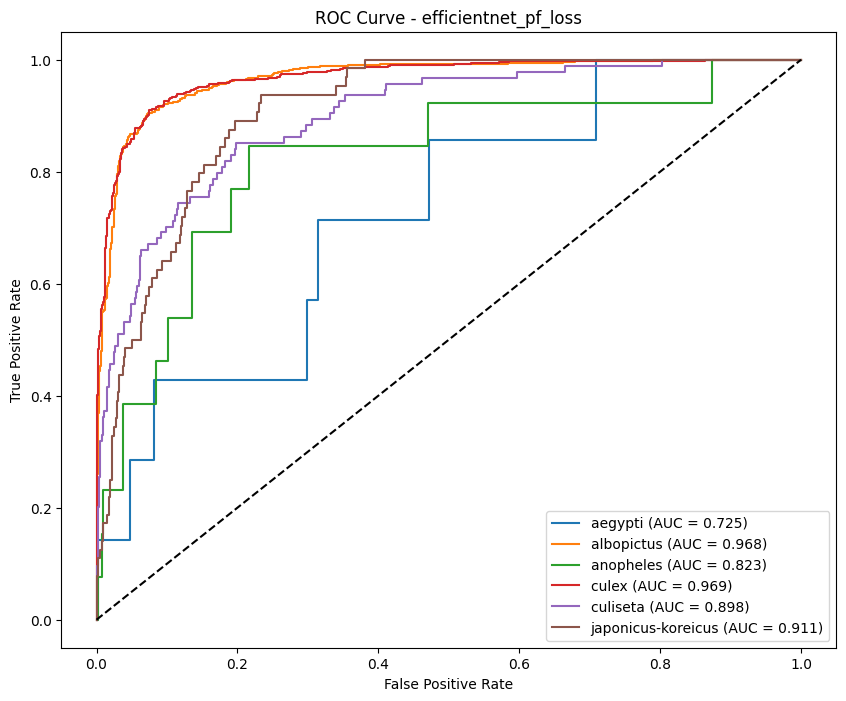

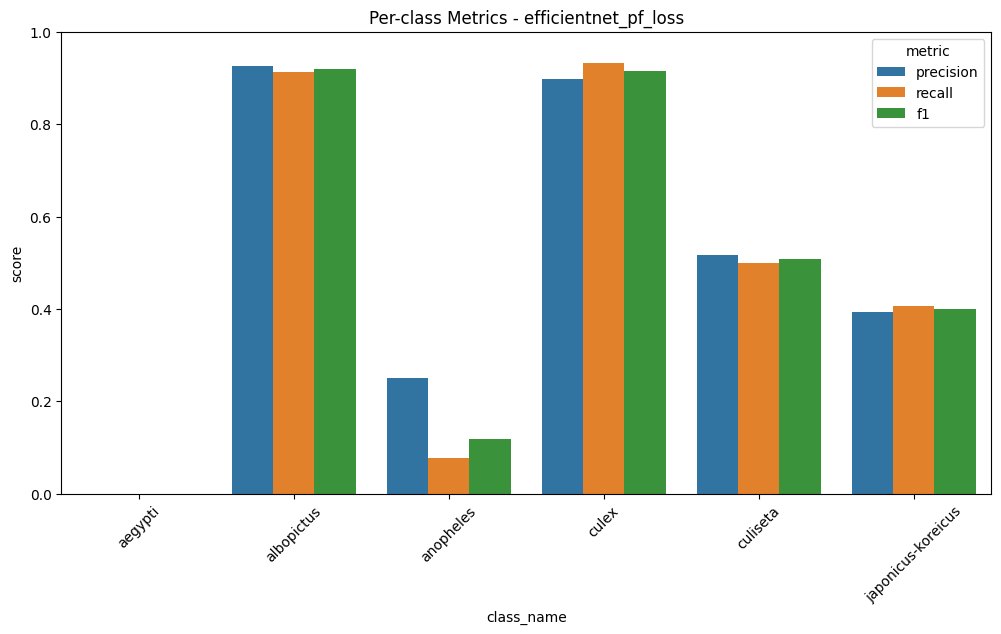


===== Results for efficientnet_stratified_sampling =====
Test Accuracy: 0.8636


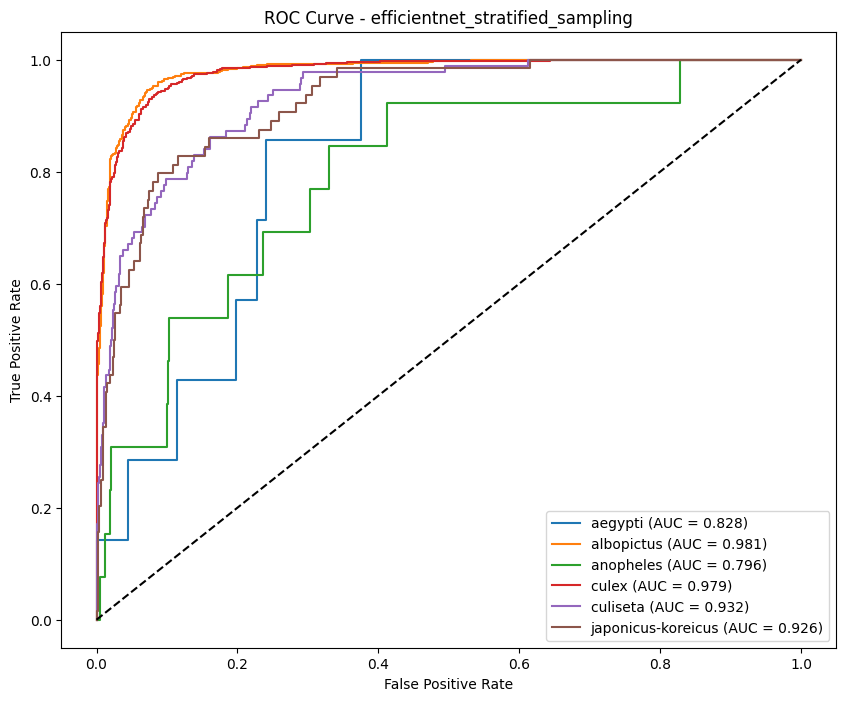

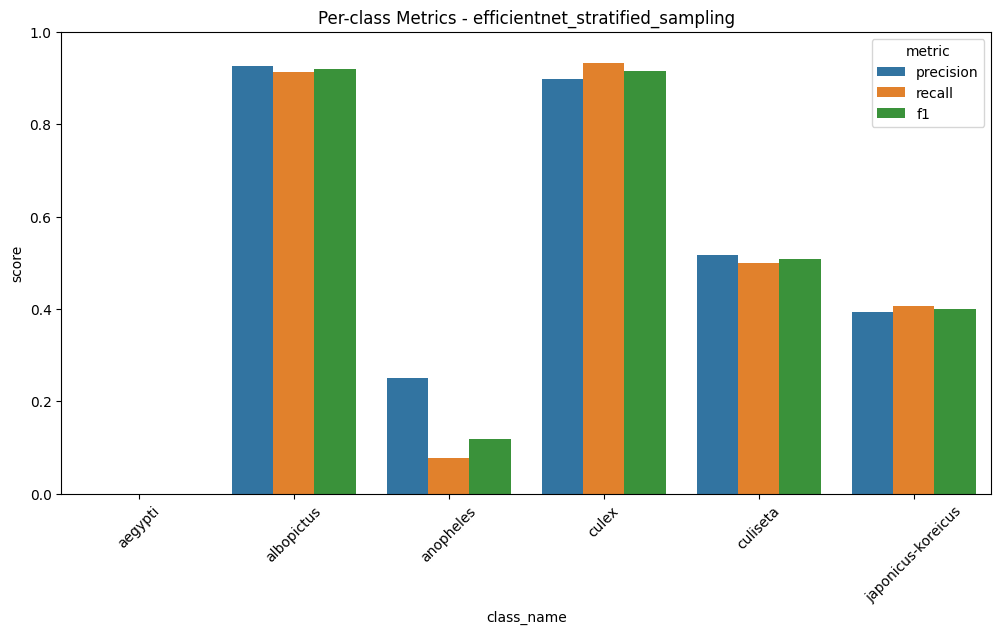


===== Results for resnet50_weighted_sampler =====
Test Accuracy: 0.9099


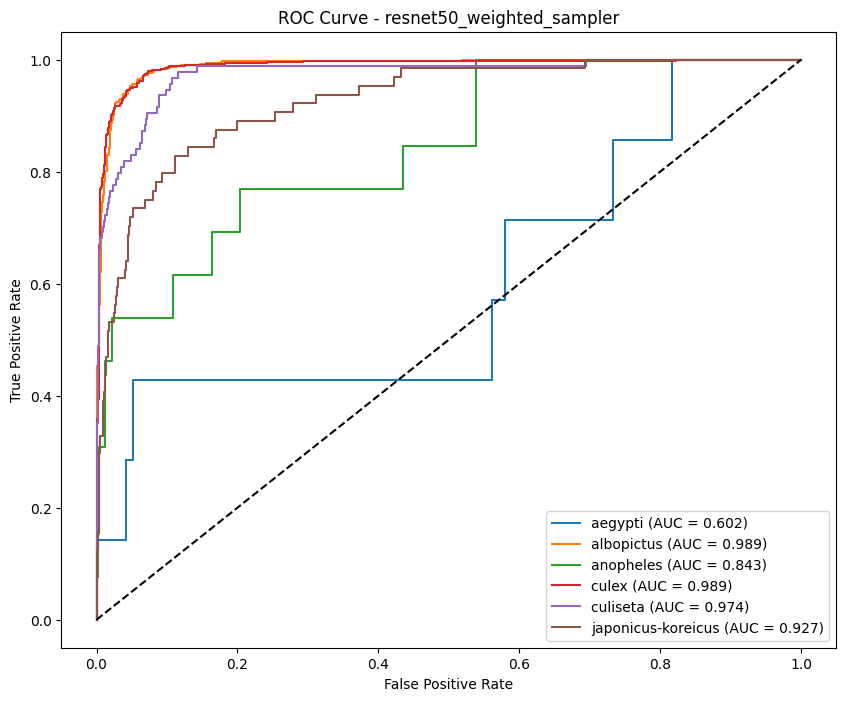

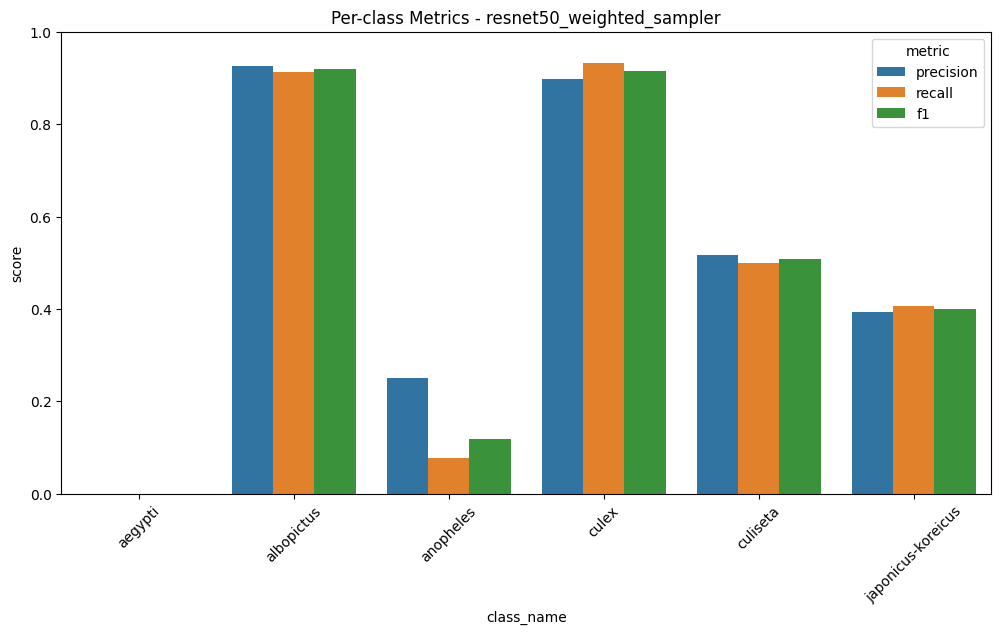


===== Results for resnet50_weighted_loss =====
Test Accuracy: 0.8616


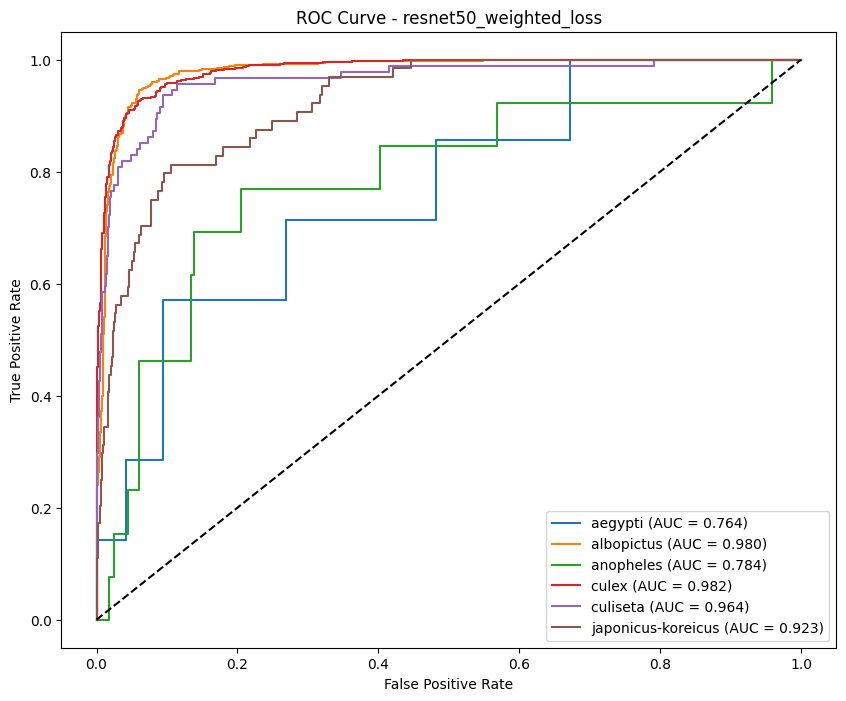

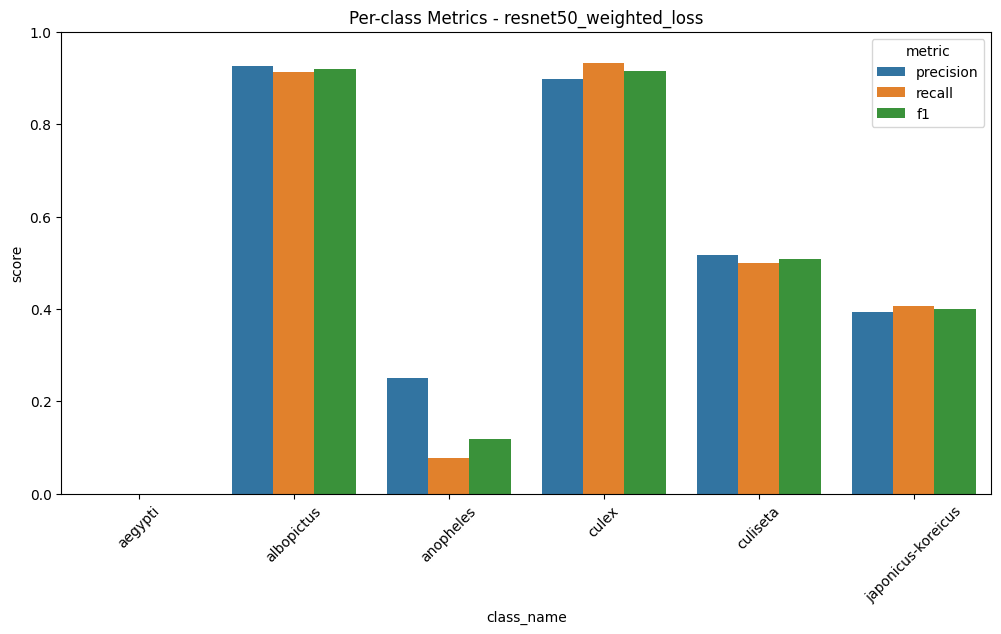


===== Results for resnet50_focal_loss =====
Test Accuracy: 0.0862


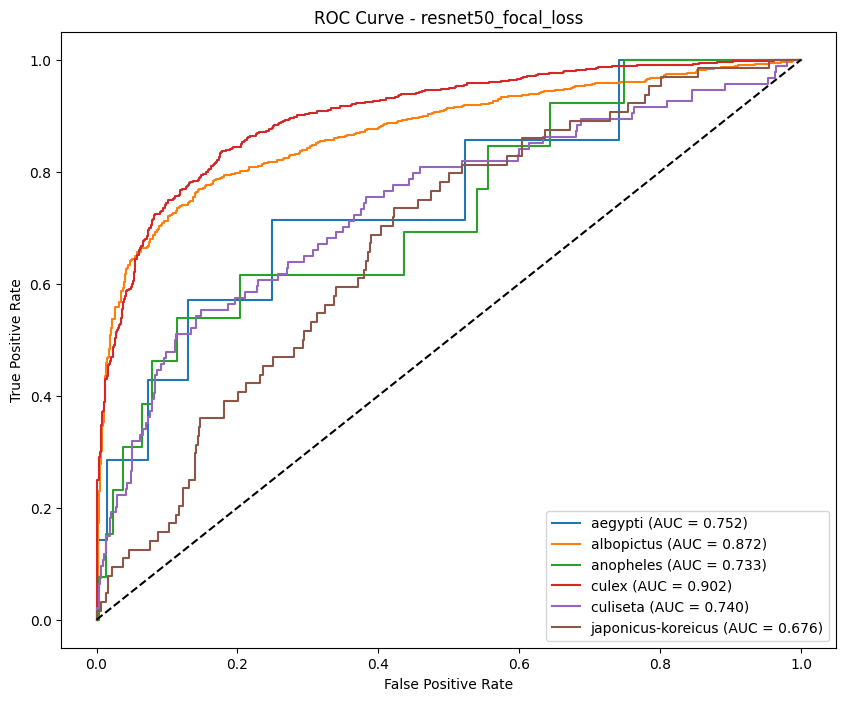

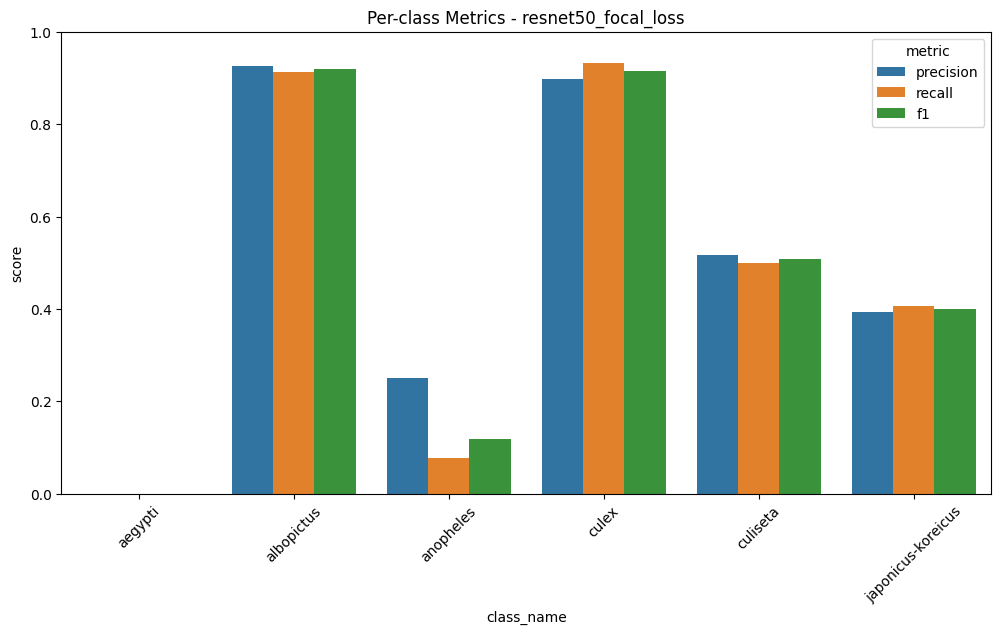


===== Results for resnet50_pf_loss =====
Test Accuracy: 0.7638


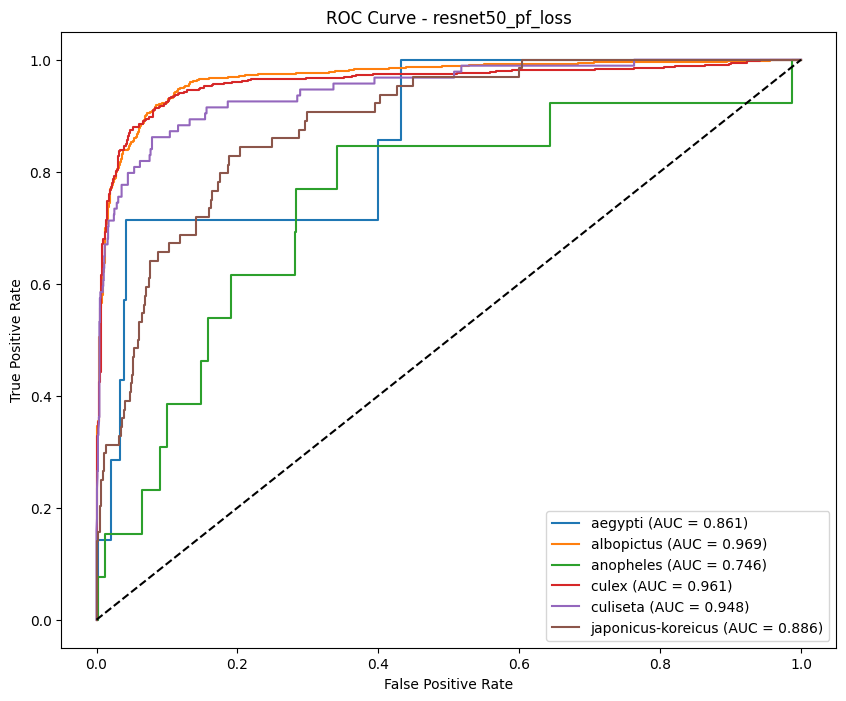

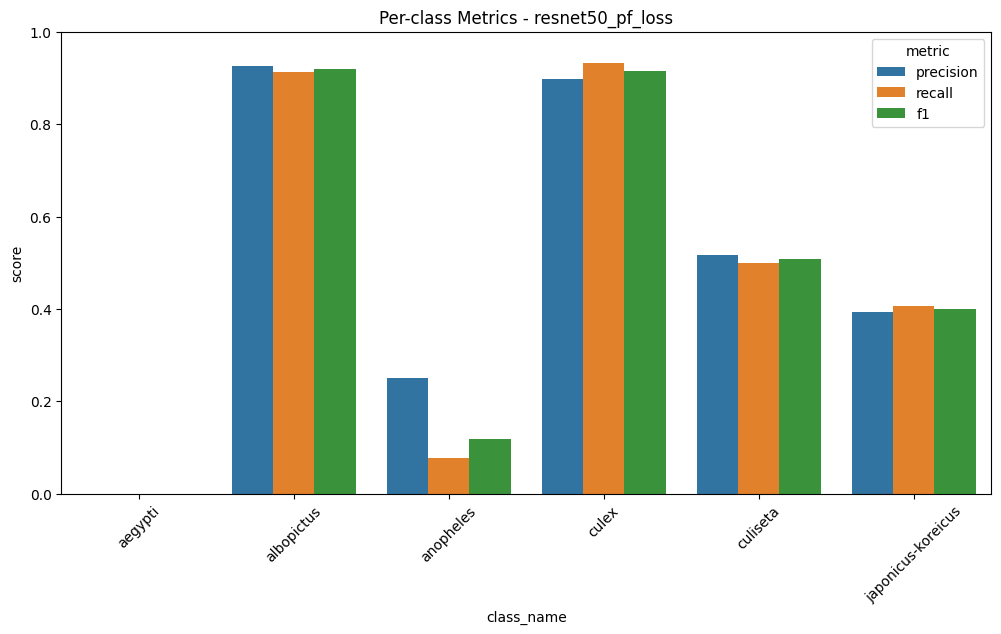


===== Results for resnet50_stratified_sampling =====
Test Accuracy: 0.906


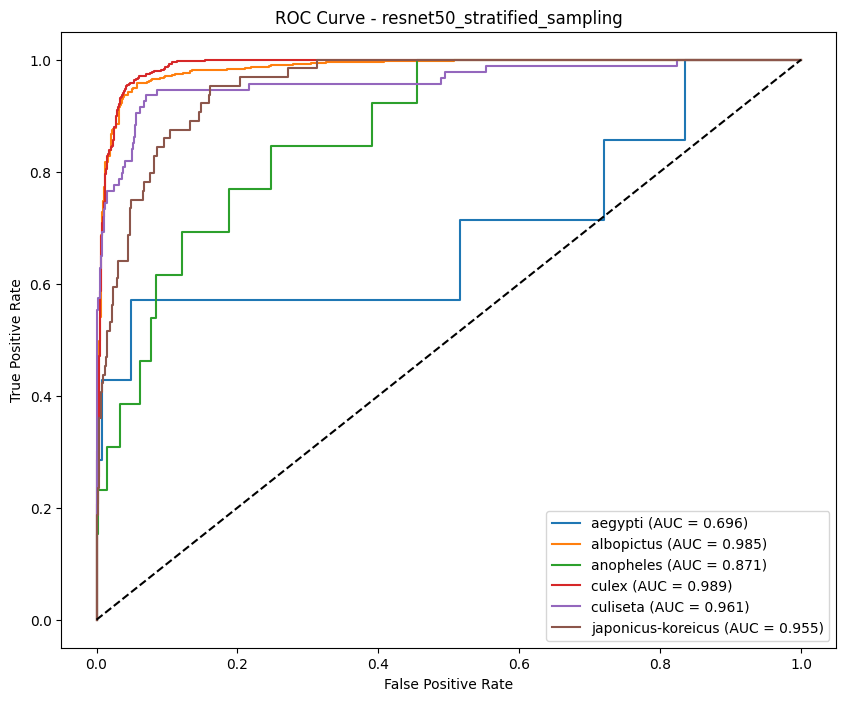

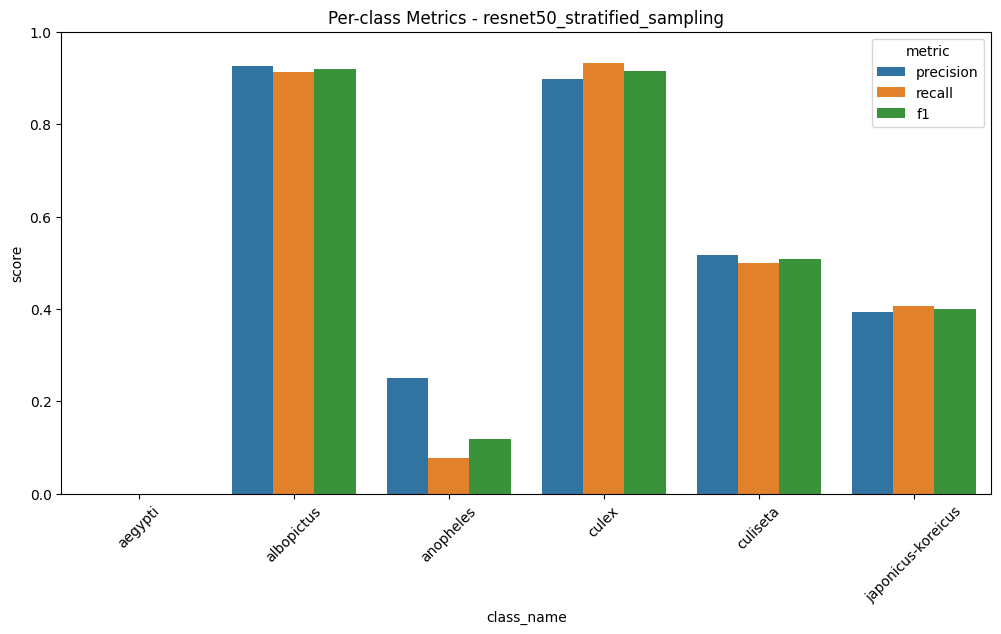


===== Results for mobilenet_weighted_sampler =====
Test Accuracy: 0.8353


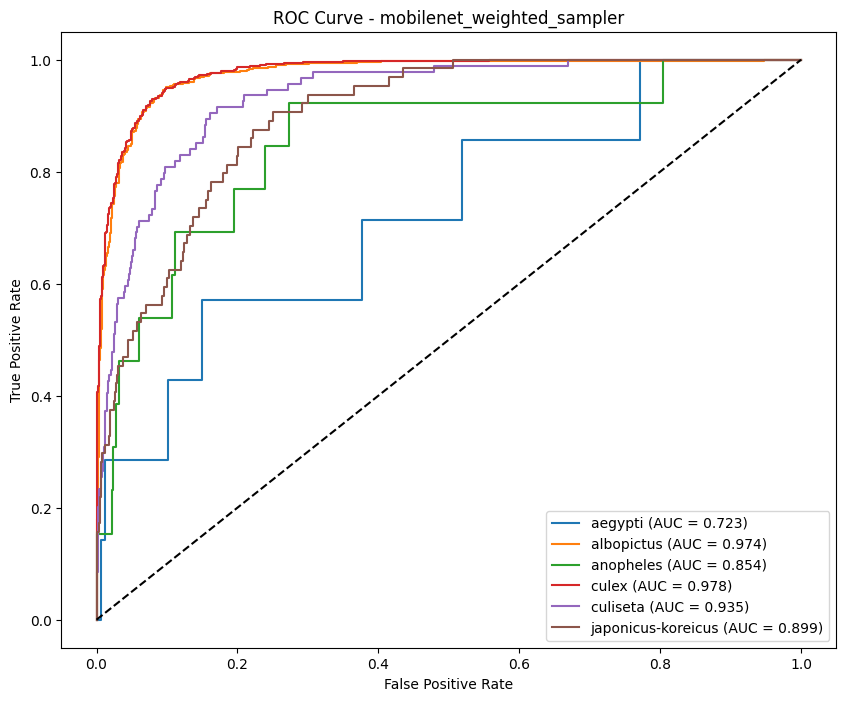

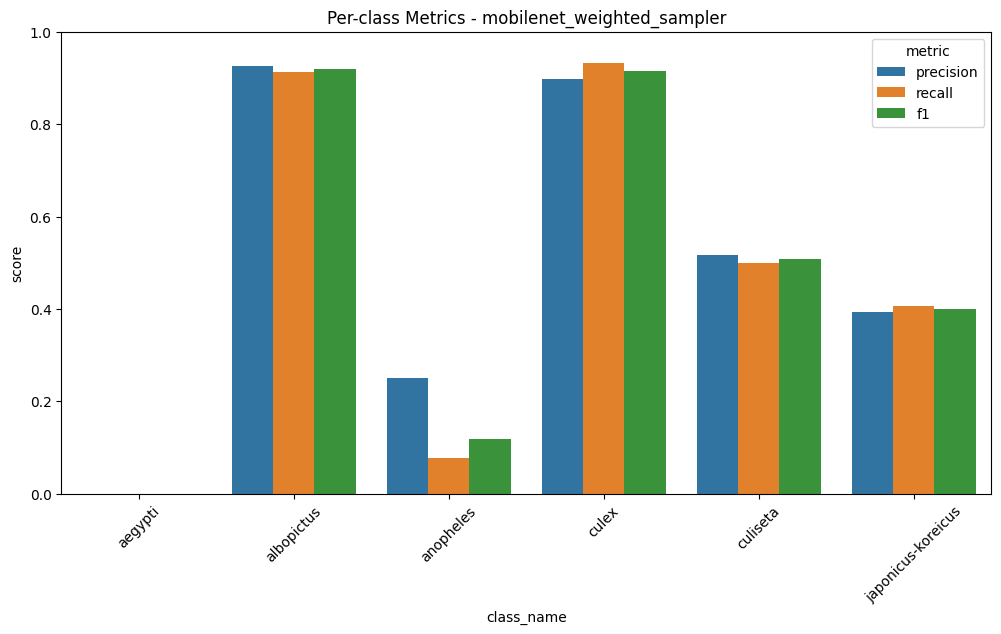


===== Results for mobilenet_weighted_loss =====
Test Accuracy: 0.7896


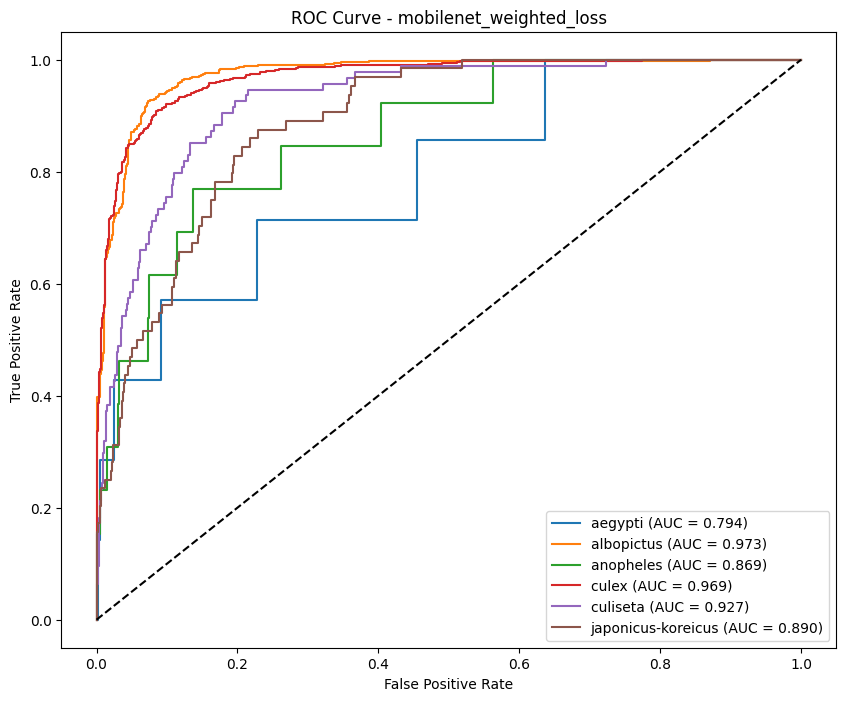

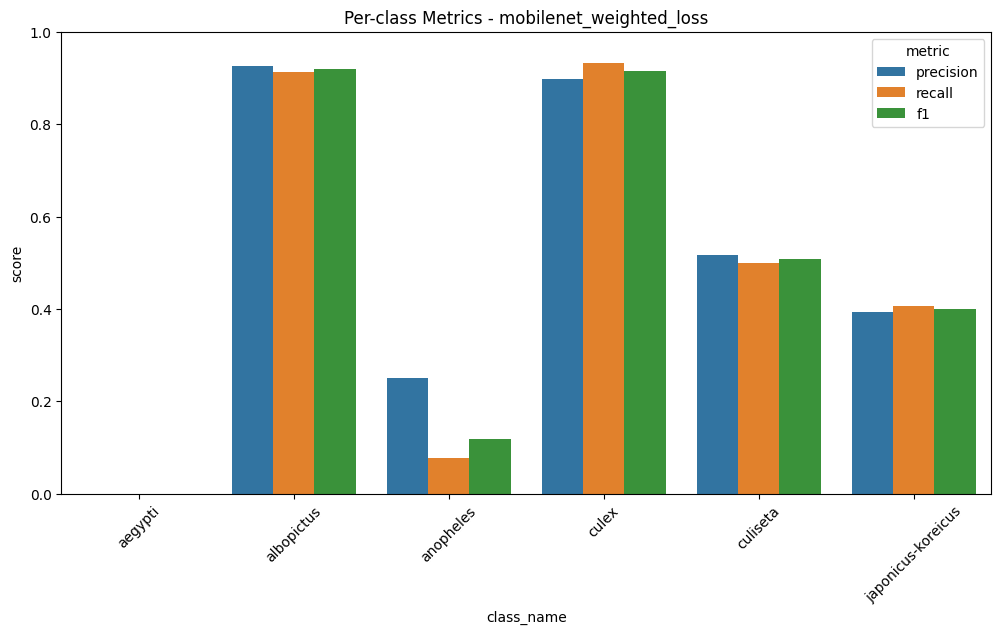


===== Results for mobilenet_focal_loss =====
Test Accuracy: 0.0541


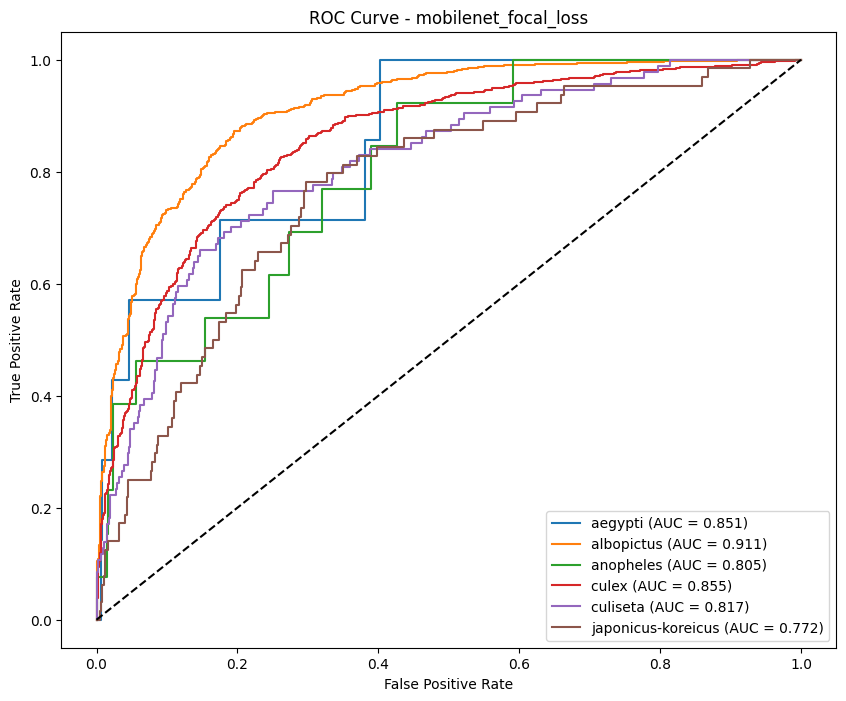

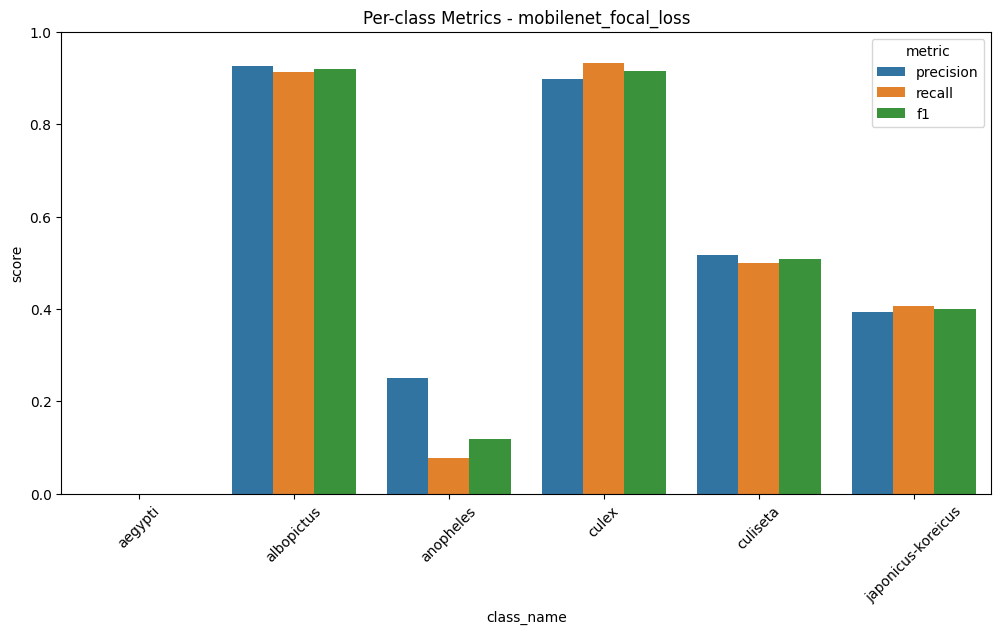


===== Results for mobilenet_pf_loss =====
Test Accuracy: 0.7851


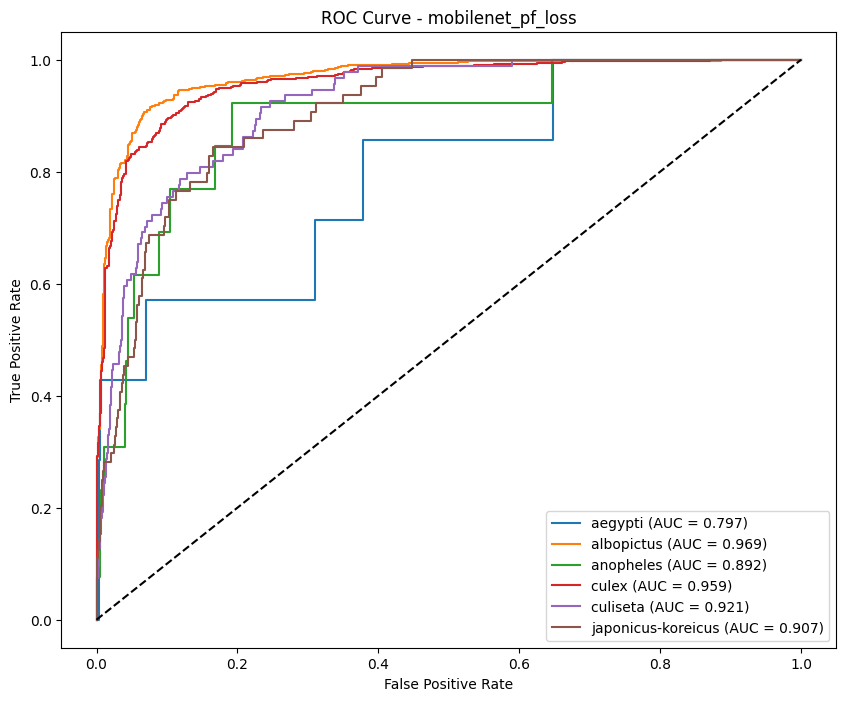

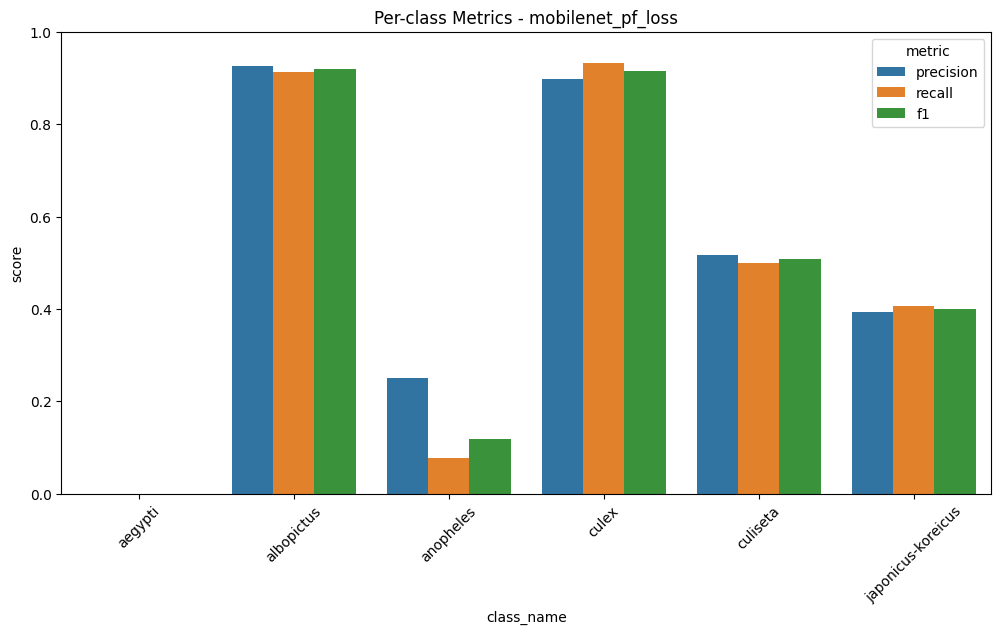


===== Results for mobilenet_stratified_sampling =====
Test Accuracy: 0.8649


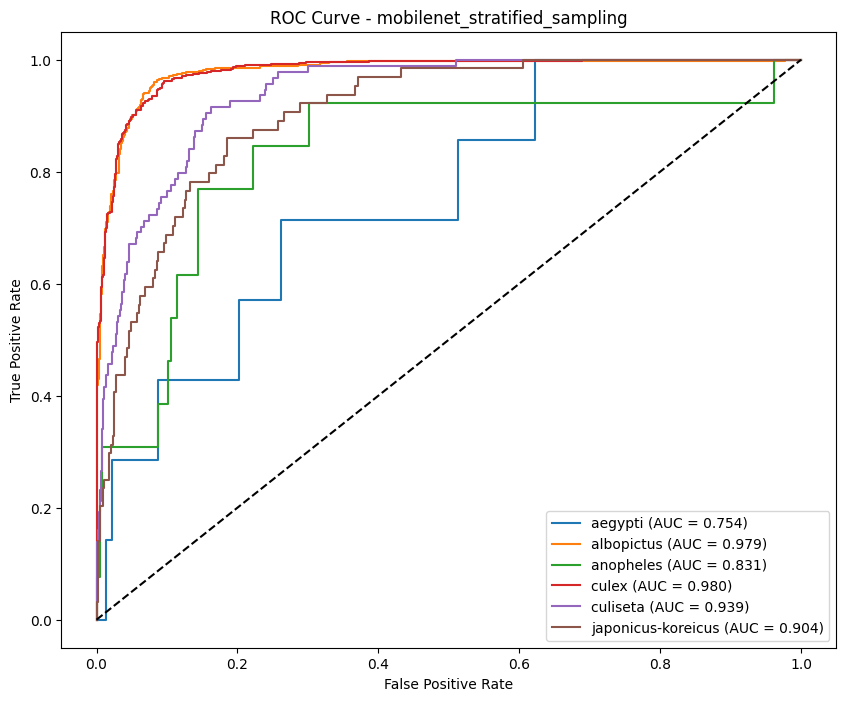

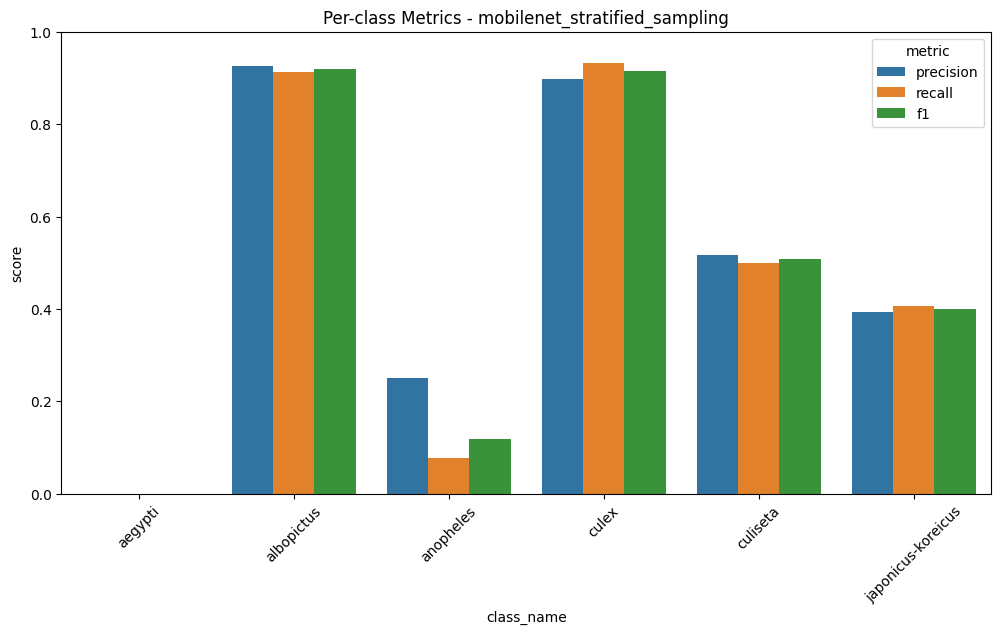

           model               method  \
5       resnet50     weighted_sampler   
9       resnet50  stratified_sampling   
6       resnet50        weighted_loss   
0   efficientnet     weighted_sampler   
4   efficientnet  stratified_sampling   
14     mobilenet  stratified_sampling   
8       resnet50              pf_loss   
10     mobilenet     weighted_sampler   
1   efficientnet        weighted_loss   
11     mobilenet        weighted_loss   
13     mobilenet              pf_loss   
3   efficientnet              pf_loss   
2   efficientnet           focal_loss   
7       resnet50           focal_loss   
12     mobilenet           focal_loss   

                                      val_acc_history  best_val_acc  \
5   [0.8468468468468469, 0.8584298584298584, 0.866...      0.911197   
9   [0.814028314028314, 0.8532818532818532, 0.8738...      0.902188   
6   [0.7586872586872587, 0.703989703989704, 0.7940...      0.868726   
0   [0.6827541827541828, 0.7072072072072072, 0.741...      

In [26]:
summary_list = []

for model_name, data in all_test_results.items():
    print(f"\n===== Results for {model_name} =====")

    all_preds = data["preds"]
    all_labels = data["labels"]
    all_probs = data["probs"]
    
    # # ===== Accuracy =====
    acc = accuracy_score(all_labels, all_preds)
    print("Test Accuracy:", round(acc, 4))

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )
    
    # # ===== Precision / Recall / F1 per class =====
    # precision, recall, f1, support = precision_recall_fscore_support(
    #     all_labels,
    #     all_preds,
    #     average=None,
    #     zero_division=0
    # )

    # per_class_df = pd.DataFrame({
    #     "class_name": class_names,
    #     "precision": precision,
    #     "recall": recall,
    #     "f1": f1,
    #     "support": support
    # })

    # ===== ROC Curve =====
    n_classes = len(class_names)
    all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    # ===== Bar chart =====
    plot_df = per_class_df.melt(
        id_vars=["class_name", "support"],
        value_vars=["precision", "recall", "f1"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.title(f"Per-class Metrics - {model_name}")
    plt.show()

    
    # ===== Macro metrics =====
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    # ===== Store summary =====
    summary_list.append({
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_ovr": roc_auc
    })

df = pd.DataFrame(all_results)
print(df.sort_values(by="best_val_acc", ascending=False))

df = pd.DataFrame(summary_list)
print(df.sort_values(by="f1_macro", ascending=False))

In [27]:
summary_df = pd.DataFrame(summary_list)
print("\n===== Model Comparison Summary =====")
print(summary_df)


===== Model Comparison Summary =====
                               model  accuracy  precision_macro  recall_macro  \
0      efficientnet_weighted_sampler  0.855856         0.488934      0.511799   
1         efficientnet_weighted_loss  0.783140         0.468495      0.604903   
2            efficientnet_focal_loss  0.101673         0.395650      0.419541   
3               efficientnet_pf_loss  0.758687         0.443669      0.557149   
4   efficientnet_stratified_sampling  0.863578         0.526049      0.527526   
5          resnet50_weighted_sampler  0.909910         0.770871      0.567015   
6             resnet50_weighted_loss  0.861647         0.491190      0.540534   
7                resnet50_focal_loss  0.086229         0.377000      0.371659   
8                   resnet50_pf_loss  0.763835         0.446248      0.556667   
9       resnet50_stratified_sampling  0.906049         0.775623      0.601778   
10        mobilenet_weighted_sampler  0.835264         0.471172      0.

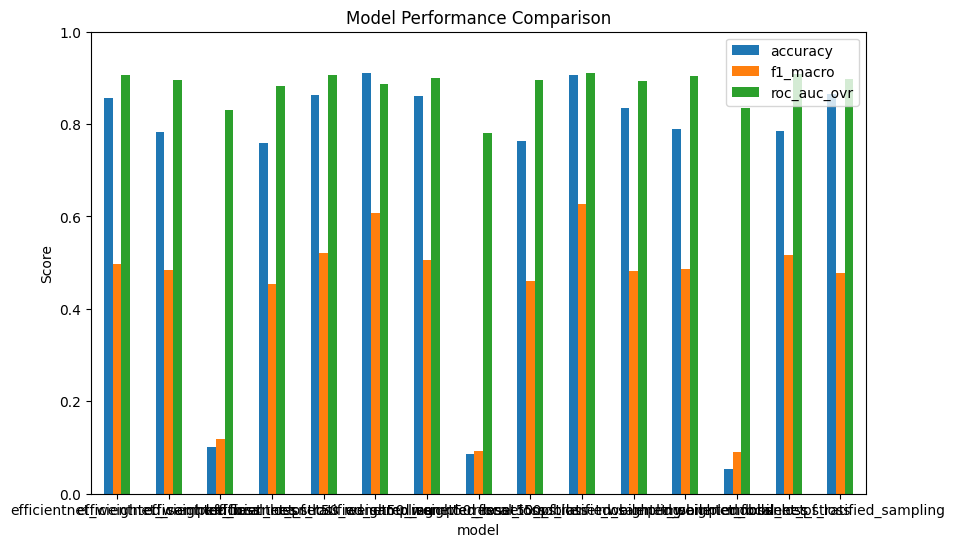

In [28]:
summary_df.set_index("model")[["accuracy", "f1_macro", "roc_auc_ovr"]].plot(
    kind="bar", figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [30]:
best = max(all_results, key=lambda x: x["best_val_acc"])

print("Best Model:", best["model"])
print("Best Method:", best["method"])
print("Best Accuracy:", best["best_val_acc"])

Best Model: resnet50
Best Method: weighted_sampler
Best Accuracy: 0.9111969111969112
